# Nzoia Basin Flood CAT Model — Team B

**An end-to-end, open-data riverine flood catastrophe model for the lower Nzoia basin (Budalangi), Kenya.**

Hazard → Vulnerability → Exposure → Financial engine → EP curve, with a trained machine-learning vulnerability model and
an LLM layer (in the web app) that ingests free-text exposure and drafts underwriter briefings.

| Stage | What this notebook does | Data status |
|---|---|---|
| 1. Hazard | Reads the six JRC river-flood depth rasters (RP10–RP500) and samples depth for every building | **Real** (JRC Global River Flood Hazard Maps) |
| 2. Vulnerability | Adapts the JRC/Huizinga (2017) Africa residential depth-damage curve per housing class, then **trains a monotone gradient-boosted model with quantile heads** on a pseudo-claims set | Curve shape: **published reference**. Class modifiers & pseudo-claims: **assumption / synthetic** |
| 3. Exposure | Audits and repairs the synthetic 500-building portfolio | **Synthetic** — not a real client portfolio |
| 4. Financial engine | Scenario losses per return period, insurance terms, Cat XL, EP curve, AAL, Monte Carlo year-loss table with secondary uncertainty | Method: standard practice; parameters: **assumption** |
| 5. Export | Writes JSON + PNG artefacts consumed by the Next.js dashboard (`web/`) | — |

> **Honesty rule used throughout:** every number is tagged as *real*, *synthetic*, or *assumption*. The exposure portfolio is
> synthetic and must never be described as real holdings. The ML vulnerability model is trained on *pseudo-claims* generated
> from a published curve plus documented modifiers — it is a calibration-ready pipeline, not evidence from real Kenyan claims.

## 0. Setup

In [2]:
import json, math, warnings, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from scipy.ndimage import distance_transform_edt
from scipy.stats import norm
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_pinball_loss
from sklearn.inspection import permutation_importance
from PIL import Image
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 30)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "team_b_nzoia"
OUT = ROOT / "outputs"
FIG = OUT / "figures"
WEB_DATA = ROOT / "web" / "public" / "data"
WEB_HAZ = ROOT / "web" / "public" / "hazard"
for p in (OUT, FIG, WEB_DATA, WEB_HAZ):
    p.mkdir(parents=True, exist_ok=True)

SEED = 2026
RPS = np.array([10, 20, 50, 100, 200, 500])
CLASSES = ["informal_iron_sheet", "semi_permanent", "permanent_masonry", "concrete_rcc"]
CLASS_LABEL = {
    "informal_iron_sheet": "Informal (iron sheet)",
    "semi_permanent": "Semi-permanent",
    "permanent_masonry": "Permanent masonry",
    "concrete_rcc": "Concrete / RCC",
}
CLASS_COLOR = {
    "informal_iron_sheet": "#e4572e",
    "semi_permanent": "#f3a712",
    "permanent_masonry": "#4f86c6",
    "concrete_rcc": "#2e4057",
}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

def kes_m(v):
    return f"KES {v/1e6:,.1f} M"

print("Project root:", ROOT)

Project root: c:\Users\jenas.DESKTOP-ERM5J4E\OneDrive\Documents\Kenya RE - Hackathon\Nzoia_Basin_Flood_Challenge


## 1. Data audit — exposure

Before modelling anything we check the synthetic portfolio against the published data dictionary
(`Dataset_Metadata.pdf`). The dictionary states that `tiv_kes = floor_area_m2 × cost_per_m2_kes`, rounded to the
nearest KES 5,000, with a portfolio total of **KES 2,273,710,000** and a median of **KES 490,000**.

In [3]:
expo_raw = pd.read_csv(DATA / "exposure_nzoia_synthetic.csv")
assert expo_raw["synthetic"].all(), "Every row must carry synthetic=True"

calc = expo_raw["floor_area_m2"] * expo_raw["cost_per_m2_kes"]
documented_tiv = (np.round(calc / 5000) * 5000)
ratio = expo_raw["tiv_kes"] / calc

qa = pd.DataFrame({
    "check": ["rows", "unique loc_id", "all synthetic=True", "lat range", "lon range",
              "file tiv_kes total", "floor_area × cost total (rounded 5k)", "metadata-stated total",
              "file tiv / (area × cost): median", "file tiv / (area × cost): min–max",
              "file tiv median", "documented tiv median (metadata says 490,000)"],
    "value": [len(expo_raw), expo_raw.loc_id.nunique(), bool(expo_raw.synthetic.all()),
              f"{expo_raw.lat.min():.3f} – {expo_raw.lat.max():.3f}", f"{expo_raw.lon.min():.3f} – {expo_raw.lon.max():.3f}",
              f"{expo_raw.tiv_kes.sum():,.0f}", f"{documented_tiv.sum():,.0f}", "2,273,710,000",
              f"{ratio.median():.4f}", f"{ratio.min():.3f} – {ratio.max():.3f}",
              f"{expo_raw.tiv_kes.median():,.0f}", f"{documented_tiv.median():,.0f}"],
})
display(qa)
display(expo_raw.housing_class.value_counts().rename("buildings").to_frame())

,check,value
0,rows,500
1,unique loc_id,500
2,all synthetic=True,True
3,lat range,-0.297 – 1.296
4,lon range,33.714 – 35.395
5,file tiv_kes total,"22,737,765,000"
6,floor_area × cost total (rounded 5k),"2,273,710,000"
7,metadata-stated total,"2,273,710,000"
8,file tiv / (area × cost): median,10.0000
9,file tiv / (area × cost): min–max,9.961 – 10.043


,buildings
housing_class,
informal_iron_sheet,168
semi_permanent,154
permanent_masonry,124
concrete_rcc,54


**Finding — the CSV's `tiv_kes` column is inflated by a factor of ~10.** Re-deriving the value from its own inputs
(`floor_area_m2 × cost_per_m2_kes`, rounded to KES 5,000) reproduces the metadata total of KES 2,273,710,000 *exactly*,
whereas the column in the file sums to KES 22.7 bn. The ratio is 10.00 ± 0.04 on every row (the residual is the rounding
having been applied before the ×10).

**Decision (assumption A-EXP-1):** the model uses the *documented* TIV (`floor_area × cost`, rounded to KES 5,000). The
original column is retained as `tiv_kes_file` so the correction is auditable, and the dashboard reports it. Using the file
value would scale every monetary output by 10×.

In [4]:
CLASS_COST_RANGE = {  # KES per m², from Dataset_Metadata.pdf §5 (published 2025 Kenyan construction-cost guides)
    "informal_iron_sheet": (5_000, 10_000),
    "semi_permanent": (8_000, 16_000),
    "permanent_masonry": (35_000, 65_000),
    "concrete_rcc": (50_000, 85_000),
}

def quality_index(cls, cost_per_m2):
    lo, hi = CLASS_COST_RANGE[cls]
    return float(np.clip((cost_per_m2 - lo) / (hi - lo), 0, 1))

expo = expo_raw.rename(columns={"tiv_kes": "tiv_kes_file"}).copy()
expo["tiv_kes"] = documented_tiv.astype(float)
expo["quality"] = [quality_index(c, v) for c, v in zip(expo.housing_class, expo.cost_per_m2_kes)]
expo["plinth_extra_m"] = 0.0
print(f"Model TIV: {kes_m(expo.tiv_kes.sum())} across {len(expo)} synthetic buildings")
expo.groupby("housing_class").agg(n=("loc_id", "size"), tiv=("tiv_kes", "sum"), median_tiv=("tiv_kes", "median"),
                                  mean_quality=("quality", "mean")).reindex(CLASSES)

Model TIV: KES 2,273.7 M across 500 synthetic buildings


,n,tiv,median_tiv,mean_quality
housing_class,,,,
informal_iron_sheet,168,"18,830,000.0000","105,000.0000",0.5033
semi_permanent,154,"76,535,000.0000","470,000.0000",0.5351
permanent_masonry,124,"672,755,000.0000","4,990,000.0000",0.5102
concrete_rcc,54,"1,505,590,000.0000","26,090,000.0000",0.4123


*Quality index (assumption A-EXP-2).* Within each housing class we rescale `cost_per_m2_kes` to a 0–1 **quality index**
using the published cost band for that class. Higher rebuild cost per m² is used as a proxy for better materials and finish
(e.g. plastered walls, raised floors). This is the only building-level attribute in the file beyond class and size, and the
ML vulnerability model uses it.

## 2. Hazard — JRC river flood depth rasters (real data)

Six GeoTIFFs, one per return period, 204 × 192 cells at 30 arc-seconds (~925 m). Dry cells hold a huge negative
no-data value (≈ −3.4×10³⁸) and must be treated as *dry* (depth 0), never averaged.

In [5]:
H_list, meta = [], None
for rp in RPS:
    with rasterio.open(DATA / f"nzoia_rp{rp}y.tif") as src:
        arr = src.read(1).astype("float64")
        m = dict(transform=src.transform, crs=str(src.crs), shape=src.shape, nodata=src.nodata, bounds=tuple(src.bounds))
        if meta is None:
            meta = m
        assert m["transform"] == meta["transform"] and m["shape"] == meta["shape"], "rasters must share a grid"
    H_list.append(np.where(np.isfinite(arr) & (arr > 0), arr, 0.0))
H = np.stack(H_list)                   # (6, rows, cols), metres, dry = 0
T = meta["transform"]
NROWS, NCOLS = meta["shape"]
X0, Y0, DX, DY = T.c, T.f, T.a, T.e     # DY is negative (north-up)
print("CRS:", meta["crs"][:40], "...")
print(f"Grid {NCOLS} cols × {NROWS} rows, cell {DX:.5f}° ({DX*111.32:.3f} km), bounds {np.round(meta['bounds'],3)}")
print("No-data value:", meta["nodata"])

haz_stats = pd.DataFrame({
    "return_period": RPS,
    "annual_exceedance_prob": 1 / RPS,
    "flooded_cells": [(H[i] > 0).sum() for i in range(6)],
    "flooded_pct": [100 * (H[i] > 0).mean() for i in range(6)],
    "median_depth_m": [np.median(H[i][H[i] > 0]) for i in range(6)],
    "p90_depth_m": [np.percentile(H[i][H[i] > 0], 90) for i in range(6)],
    "max_depth_m": [H[i].max() for i in range(6)],
})
haz_stats

CRS: EPSG:4326 ...
Grid 204 cols × 192 rows, cell 0.00833° (0.928 km), bounds [33.7 -0.3 35.4  1.3]
No-data value: -3.4028230607370965e+38


,return_period,annual_exceedance_prob,flooded_cells,flooded_pct,median_depth_m,p90_depth_m,max_depth_m
0,10,0.1000,3414,8.7163,0.4850,1.6000,11.9800
1,20,0.0500,3510,8.9614,0.5400,1.6500,12.3900
2,50,0.0200,3628,9.2627,0.6100,1.7100,12.8300
3,100,0.0100,3721,9.5001,0.6500,1.7900,13.1100
4,200,0.0050,3768,9.6201,0.6900,1.8730,13.3700
5,500,0.0020,3857,9.8473,0.7400,1.9480,13.6900


In [6]:
# Physical consistency: depth at a cell should not fall as the event gets rarer.
dec = (np.diff(H, axis=0) < -1e-6)
print("Cells where depth decreases between consecutive return periods:", int(dec.any(axis=0).sum()))
newly_wet = [(H[i] > 0) & ~(H[i - 1] > 0) for i in range(1, 6)]
print("Cells newly flooded at each step RP20..RP500:", [int(x.sum()) for x in newly_wet])
H_mono = np.maximum.accumulate(H, axis=0)
print("Max change from enforcing monotonicity (m):", float(np.abs(H_mono - H).max()))
H = H_mono

Cells where depth decreases between consecutive return periods: 0
Cells newly flooded at each step RP20..RP500: [96, 118, 93, 47, 89]
Max change from enforcing monotonicity (m): 0.0


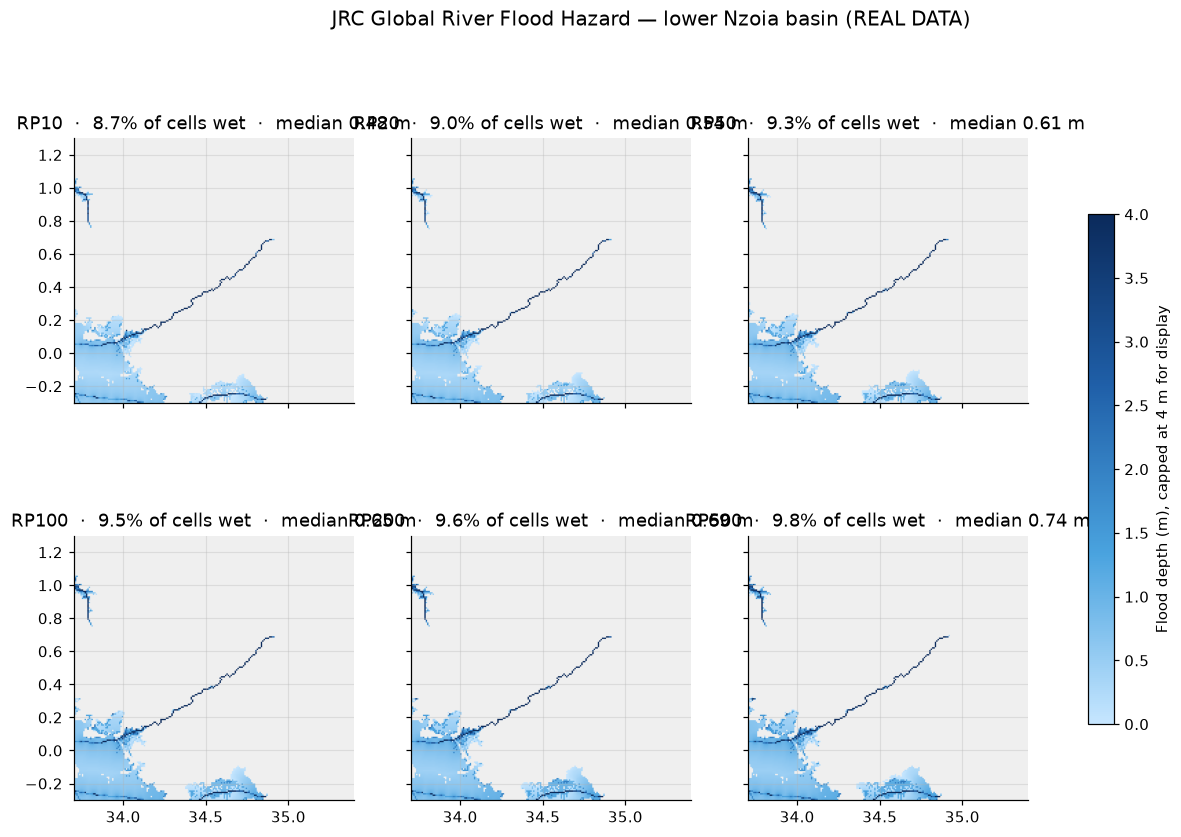

In [7]:
depth_cmap = mcolors.LinearSegmentedColormap.from_list("depth", ["#c6e6ff", "#4aa3df", "#1f5fa8", "#0b2a5b"])
fig, axes = plt.subplots(2, 3, figsize=(14, 8.6), sharex=True, sharey=True)
ext = [meta["bounds"][0], meta["bounds"][2], meta["bounds"][1], meta["bounds"][3]]
for ax, i in zip(axes.flat, range(6)):
    ax.set_facecolor("#efefef")
    im = ax.imshow(np.where(H[i] > 0, H[i], np.nan), cmap=depth_cmap, norm=mcolors.Normalize(0, 4), extent=ext)
    ax.set_title(f"RP{RPS[i]}  ·  {haz_stats.flooded_pct[i]:.1f}% of cells wet  ·  median {haz_stats.median_depth_m[i]:.2f} m")
fig.colorbar(im, ax=axes, shrink=0.7, label="Flood depth (m), capped at 4 m for display")
fig.suptitle("JRC Global River Flood Hazard — lower Nzoia basin (REAL DATA)", fontsize=13)
fig.savefig(FIG / "hazard_panels.png", bbox_inches="tight"); plt.show()

**What the hazard says:** flooding is confined to a narrow corridor along the Nzoia River and its Lake Victoria mouth. The
footprint barely grows from RP10 (8.7 % of cells) to RP500 (9.8 %) but depth keeps rising. Expect a loss curve that jumps
once at the frequent end and then climbs slowly — the dominant driver of rarer losses is *deeper* water on the same
buildings, not *more* buildings getting wet.

### 2.1 Sampling depth at each building

Two sampling modes are computed:

* **Point (default):** the depth of the cell that contains the building — the method the brief prescribes.
* **Bilinear (sensitivity):** a distance-weighted blend of the four nearest cell centres (dry = 0). A 925 m cell cannot tell
  a house on a rise from one in a hollow, so this mode tests how much the result depends on where the cell edges happen to
  fall. It is reported as a sensitivity, not the headline.

In [8]:
def sample_point(lat, lon, H=H):
    r, c = rowcol(T, np.asarray(lon), np.asarray(lat))
    r, c = np.asarray(r), np.asarray(c)
    inside = (r >= 0) & (r < NROWS) & (c >= 0) & (c < NCOLS)
    out = np.zeros((len(r), H.shape[0]))
    out[inside] = H[:, r[inside], c[inside]].T
    return out, r, c

def sample_bilinear(lat, lon, H=H):
    cf = (np.asarray(lon) - X0) / DX - 0.5
    rf = (np.asarray(lat) - Y0) / DY - 0.5
    c0, r0 = np.floor(cf).astype(int), np.floor(rf).astype(int)
    wc, wr = cf - c0, rf - r0
    out = np.zeros((len(cf), H.shape[0]))
    for dr_, dc_, w in [(0, 0, (1 - wr) * (1 - wc)), (0, 1, (1 - wr) * wc), (1, 0, wr * (1 - wc)), (1, 1, wr * wc)]:
        rr, cc = np.clip(r0 + dr_, 0, NROWS - 1), np.clip(c0 + dc_, 0, NCOLS - 1)
        out += w[:, None] * H[:, rr, cc].T
    return out

D_point, b_row, b_col = sample_point(expo.lat, expo.lon)
D_bilin = sample_bilinear(expo.lat, expo.lon)
for i, rp in enumerate(RPS):
    expo[f"d{rp}"] = D_point[:, i]
    expo[f"db{rp}"] = D_bilin[:, i]
expo["row"], expo["col"] = b_row, b_col

# distance (km) from every building to the nearest RP100-flooded cell centre: accumulation "near the footprint"
km_per_cell = DX * 111.32
dist_cells = distance_transform_edt(~(H[3] > 0))
expo["dist_rp100_km"] = dist_cells[b_row, b_col] * km_per_cell

wet = pd.DataFrame({
    "return_period": RPS,
    "buildings_wet_point": [(D_point[:, i] > 0).sum() for i in range(6)],
    "buildings_wet_bilinear": [(D_bilin[:, i] > 0.01).sum() for i in range(6)],
    "TIV_wet_point": [expo.tiv_kes[D_point[:, i] > 0].sum() for i in range(6)],
    "mean_depth_wet_point_m": [D_point[D_point[:, i] > 0, i].mean() for i in range(6)],
})
display(wet)
print("Metadata states 46–48 buildings sit in a flooded cell depending on the map — reproduced above.")

,return_period,buildings_wet_point,buildings_wet_bilinear,TIV_wet_point,mean_depth_wet_point_m
0,10,46,55,"162,375,000.0000",0.7198
1,20,48,57,"167,660,000.0000",0.7767
2,50,48,57,"167,660,000.0000",0.8737
3,100,48,57,"167,660,000.0000",0.9415
4,200,48,57,"167,660,000.0000",1.0037
5,500,48,57,"167,660,000.0000",1.0762


Metadata states 46–48 buildings sit in a flooded cell depending on the map — reproduced above.


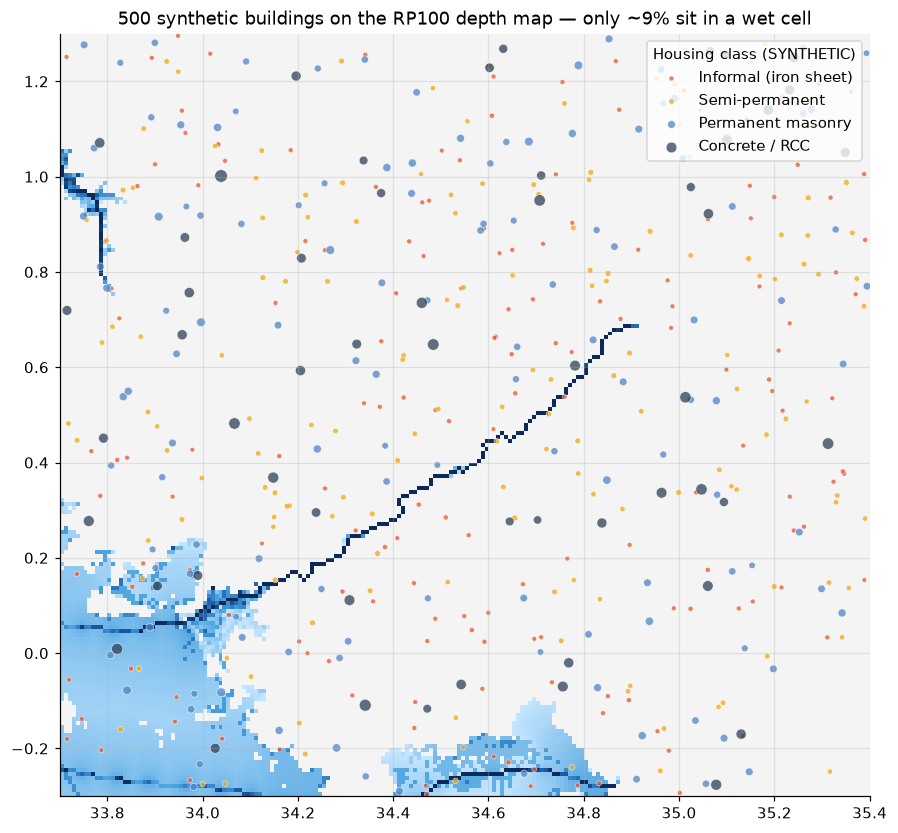

In [9]:
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_facecolor("#f4f4f4")
ax.imshow(np.where(H[3] > 0, H[3], np.nan), cmap=depth_cmap, norm=mcolors.Normalize(0, 4), extent=ext)
for cls in CLASSES:
    s = expo[expo.housing_class == cls]
    ax.scatter(s.lon, s.lat, s=8 + 60 * np.sqrt(s.tiv_kes / expo.tiv_kes.max()), c=CLASS_COLOR[cls],
               label=CLASS_LABEL[cls], alpha=0.75, edgecolor="white", linewidth=0.4)
ax.legend(loc="upper right", title="Housing class (SYNTHETIC)")
ax.set_title("500 synthetic buildings on the RP100 depth map — only ~9% sit in a wet cell")
fig.savefig(FIG / "portfolio_on_rp100.png", bbox_inches="tight"); plt.show()

## 3. Vulnerability — from a published curve to a trained ML model

### 3.1 Reference curve: JRC / Huizinga et al. (2017)

*Huizinga, J., de Moel, H., Szewczyk, W. (2017). Global flood depth-damage functions: Methodology and the database with
guidelines. JRC Technical Report EUR 28552 EN, doi:10.2760/16510.*

The report publishes normalised damage factors (fraction of maximum damage) at fixed depths per continent and occupancy.
We use **Africa – residential buildings** as the primary reference and **Global – residential** as a secondary reference
to represent between-source (epistemic) uncertainty. *The factor values below were transcribed from the report's tables;
they should be re-checked against the PDF before any production use.*

In [10]:
JRC_DEPTH = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0])
JRC_CURVES = {
    "africa_residential": np.array([0.000, 0.220, 0.378, 0.531, 0.636, 0.817, 0.903, 0.957, 1.000]),
    "global_residential": np.array([0.000, 0.326, 0.494, 0.618, 0.719, 0.867, 0.938, 0.986, 1.000]),
}

def jrc_factor(depth, curve="africa_residential"):
    return np.interp(depth, JRC_DEPTH, JRC_CURVES[curve])   # flat at 1.0 beyond 6 m

pd.DataFrame({"depth_m": JRC_DEPTH, **{k: v for k, v in JRC_CURVES.items()}})

,depth_m,africa_residential,global_residential
0,0.0000,0.0000,0.0000
1,0.5000,0.2200,0.3260
2,1.0000,0.3780,0.4940
3,1.5000,0.5310,0.6180
4,2.0000,0.6360,0.7190
5,3.0000,0.8170,0.8670
6,4.0000,0.9030,0.9380
7,5.0000,0.9570,0.9860
8,6.0000,1.0000,1.0000


### 3.2 Adapting the curve to Kenyan housing classes

No Kenya-specific depth-damage curve exists publicly. We keep the JRC *shape* and adapt it per class with four
transparent parameters. The adapted damage ratio for a building at water depth $d$ is

$$\mathrm{DR}(d) = \underbrace{\text{max\_damage}}_{\text{ceiling}} \times \mathrm{JRC}\big(\,\text{depth\_mult}\times\max(d-\text{plinth},0)\,\big)$$

| Parameter | Meaning | Grounded in | Guess? |
|---|---|---|---|
| `plinth_m` | floor height above ground: water below it does ~no structural damage | typical construction practice | **assumption** |
| `depth_mult` | >1 = the class reaches a given damage at shallower water (weak walls); <1 = more resistant | JRC shape kept; scaling is ours | **assumption** |
| `max_damage` | ceiling on damage ratio — land/foundation survive; brief says 80–95 % | problem statement & JRC max-damage logic | partly grounded |
| `dur_k`, `quality_k` | sensitivity to flood duration and to build quality (pseudo-claims generator only) | literature direction (long inundation weakens earth/mud walls); magnitude ours | **assumption** |

,plinth_m,depth_mult,max_damage,dur_k,quality_k,rationale
housing_class,,,,,,
informal_iron_sheet,0.0000,1.3500,0.9500,0.1400,0.2000,"Mud/timber walls with iron-sheet roof, floor a..."
semi_permanent,0.0500,1.1500,0.9000,0.1000,0.2000,Earth-block or timber with cement screed; slig...
permanent_masonry,0.2000,1.0000,0.8500,0.0600,0.1500,Fired brick/stone on a raised slab; treated as...
concrete_rcc,0.3000,0.8000,0.7500,0.0300,0.1500,"Reinforced-concrete frame, often multi-storey ..."


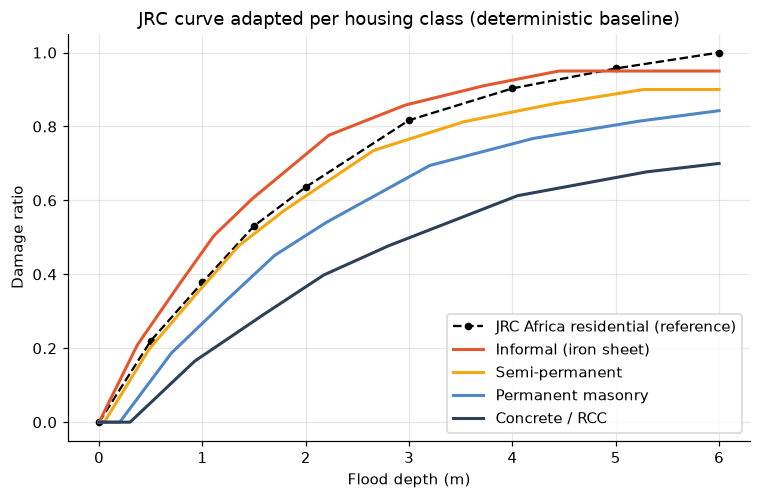

In [11]:
CLASS_PARAMS = pd.DataFrame([
    dict(housing_class="informal_iron_sheet", plinth_m=0.00, depth_mult=1.35, max_damage=0.95, dur_k=0.14, quality_k=0.20,
         rationale="Mud/timber walls with iron-sheet roof, floor at ground level; walls slump in prolonged water, little salvage."),
    dict(housing_class="semi_permanent", plinth_m=0.05, depth_mult=1.15, max_damage=0.90, dur_k=0.10, quality_k=0.20,
         rationale="Earth-block or timber with cement screed; slightly raised floor; moderately water-sensitive."),
    dict(housing_class="permanent_masonry", plinth_m=0.20, depth_mult=1.00, max_damage=0.85, dur_k=0.06, quality_k=0.15,
         rationale="Fired brick/stone on a raised slab; treated as the JRC residential baseline."),
    dict(housing_class="concrete_rcc", plinth_m=0.30, depth_mult=0.80, max_damage=0.75, dur_k=0.03, quality_k=0.15,
         rationale="Reinforced-concrete frame, often multi-storey (upper floors unaffected); structure survives, finishes/services damaged."),
]).set_index("housing_class")

def adapted_dr(depth, cls, curve="africa_residential"):
    p = CLASS_PARAMS.loc[cls]
    eff = np.clip(np.asarray(depth, dtype=float) - p.plinth_m, 0, None) * p.depth_mult
    return p.max_damage * jrc_factor(eff, curve)

display(CLASS_PARAMS)
dd = np.linspace(0, 6, 241)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(JRC_DEPTH, JRC_CURVES["africa_residential"], "k--o", ms=4, label="JRC Africa residential (reference)")
for cls in CLASSES:
    ax.plot(dd, adapted_dr(dd, cls), color=CLASS_COLOR[cls], lw=2, label=CLASS_LABEL[cls])
ax.set(xlabel="Flood depth (m)", ylabel="Damage ratio", title="JRC curve adapted per housing class (deterministic baseline)")
ax.legend(); fig.savefig(FIG / "vuln_adapted.png", bbox_inches="tight"); plt.show()

### 3.3 Pseudo-claims training set (synthetic)

The brief suggests "a regression model to fit or adjust vulnerability curves if you create a small synthetic claims dataset to
train against". No real flood claims are available, so we **generate 30,000 pseudo-claims** that encode what a loss adjuster
would observe if the adapted curves were correct *on average* but individual buildings scattered around them:

1. **Hazard sample:** depth drawn from a mixture weighted to shallow water (70 % exponential with mean 1.2 m, 30 % uniform 0–7 m);
   flood duration lognormal with a median of 7 days (Budalangi floods typically stand for days to weeks) clipped to 1–45 days.
2. **Building sample:** class (balanced, so RCC is well represented), quality index U(0, 1).
3. **Reference curve uncertainty:** each claim is generated from the Africa (70 %) or Global (30 %) JRC residential curve —
   the model has to learn the spread *between published sources*, not a single line.
4. **Expected damage:** adapted curve × duration modifier $1 + k_{dur}\ln(\text{dur}/7)$ × quality modifier
   $1 - k_q(q-0.5)$, capped at the class ceiling.
5. **Observed damage:** Beta-distributed around the expectation (precision φ = 15) — building-to-building scatter; plus a
   zero-claim probability $0.5\,e^{-d/0.2}$ at very shallow depths (water that never crosses the threshold).

**Why train a model on synthetic claims at all?** (a) It turns a point curve into a *distribution* (quantile heads), which the
Monte Carlo engine needs for secondary uncertainty; (b) it lets building-level attributes (quality, duration) change the loss
of each building rather than one line per class; (c) the exact same pipeline can be re-fitted on real loss-adjuster data
(e.g. March 2026 Budalangi claims) the moment a cedant supplies it. What it **cannot** do is discover a damage pattern we did
not put in — we say this plainly in the dashboard.

In [12]:
def generate_pseudo_claims(n, seed=SEED):
    g = np.random.default_rng(seed)
    cls = g.choice(CLASSES, n)
    depth = np.where(g.random(n) < 0.7, g.exponential(1.2, n), g.uniform(0, 7, n)).clip(0.02, 8.0)
    duration = np.exp(g.normal(np.log(7), 0.8, n)).clip(1, 45)
    quality = g.uniform(0, 1, n)
    source = g.choice(list(JRC_CURVES), n, p=[0.7, 0.3])
    P = CLASS_PARAMS.loc[cls]
    eff = np.clip(depth - P.plinth_m.values, 0, None) * P.depth_mult.values
    base = P.max_damage.values * np.where(source == "africa_residential",
                                          jrc_factor(eff, "africa_residential"), jrc_factor(eff, "global_residential"))
    dur_mod = 1 + P.dur_k.values * np.log(duration / 7)
    q_mod = 1 - P.quality_k.values * (quality - 0.5)
    mu = np.clip(base * dur_mod * q_mod, 0, P.max_damage.values)
    phi = 15.0
    obs = g.beta(mu * phi + 1e-3, (1 - mu) * phi + 1e-3)
    zero = g.random(n) < 0.5 * np.exp(-depth / 0.2)
    obs = np.where(zero | (mu <= 1e-6), 0.0, np.clip(obs, 0, 1))
    return pd.DataFrame(dict(housing_class=cls, depth_m=depth, duration_days=duration, quality=quality,
                             reference_curve=source, expected_dr=mu, damage_ratio=obs, synthetic=True))

claims = generate_pseudo_claims(30_000)
claims.to_csv(OUT / "pseudo_claims_synthetic.csv", index=False)
display(claims.head())
claims.groupby("housing_class")[["depth_m", "duration_days", "damage_ratio"]].describe().T.round(3)

,housing_class,depth_m,duration_days,quality,reference_curve,expected_dr,damage_ratio,synthetic
0,concrete_rcc,0.0371,12.0125,0.1948,global_residential,0.0000,0.0000,True
1,informal_iron_sheet,0.0634,2.8233,0.9796,global_residential,0.0418,0.0000,True
2,informal_iron_sheet,2.3104,23.3954,0.6755,africa_residential,0.8864,0.9596,True
3,permanent_masonry,0.0296,17.3353,0.1552,africa_residential,0.0000,0.0000,True
4,semi_permanent,0.6527,4.8087,0.7331,africa_residential,0.2321,0.0722,True


housing_class        concrete_rcc  informal_iron_sheet  permanent_masonry  \
depth_m       count    7,537.0000           7,470.0000         7,500.0000   
              mean         1.8830               1.8840             1.8920   
              std          1.8280               1.8300             1.8280   
              min          0.0200               0.0200             0.0200   
              25%          0.4810               0.4660             0.4850   
              50%          1.2070               1.2010             1.2250   
              75%          2.7750               2.7740             2.7640   
              max          8.0000               8.0000             8.0000   
duration_days count    7,537.0000           7,470.0000         7,500.0000   
              mean         9.6400               9.5620             9.5360   
              std          8.2970               8.1780             8.1290   
              min          1.0000               1.0000             1.0000   
              25%          4.1180               4.1480             4.1570   
              50%          7.0150               7.0360             6.9570   
              75%         12.1120              12.0210            12.0460   
              max         45.0000              45.0000            45.0000   
damage_ratio  count    7,537.0000           7,470.0000         7,500.0000   
              mean         0.2870               0.5320             0.3810   
              std          0.2640               0.3270             0.3030   
              min          0.0000               0.0000             0.0000   
              25%          0.0240               0.2470             0.0890   
              50%          0.2330               0.5550             0.3520   
              75%          0.4960               0.8440             0.6470   
              max          0.9750               1.0000             0.9930   

housing_class        semi_permanent  
depth_m       count      7,493.0000  
              mean           1.8400  
              std            1.8020  
              min            0.0200  
              25%            0.4600  
              50%            1.1870  
              75%            2.6930  
              max            8.0000  
duration_days count      7,493.0000  
              mean           9.5560  
              std            8.0850  
              min            1.0000  
              25%            4.1380  
              50%            7.1420  
              75%           12.0280  
              max           45.0000  
damage_ratio  count      7,493.0000  
              mean           0.4530  
              std            0.3120  
              min            0.0000  
              25%            0.1740  
              50%            0.4400  
              75%            0.7350  
              max            0.9970

### 3.4 Model training

* **Model:** `HistGradientBoostingRegressor` (scikit-learn), housing class as a native categorical feature.
* **Physical constraints** enforced through `monotonic_cst`: damage can only rise with depth (+1) and duration (+1) and only
  fall with quality (−1). This prevents the model from learning noise wiggles that would be indefensible to an underwriter.
* **Heads:** a mean model (squared error — used for deterministic losses and AAL) and five quantile models
  (5/25/50/75/95 % — used for secondary uncertainty in the Monte Carlo engine).
* **Baselines for comparison:** (i) the deterministic adapted JRC curve, (ii) a per-class 3-parameter logistic curve fitted by
  least squares (the "sigmoid" approach from the brief).

In [13]:
FEATURES = ["class_code", "depth_m", "duration_days", "quality"]
CLASS_CODE = {c: i for i, c in enumerate(CLASSES)}
claims["class_code"] = claims.housing_class.map(CLASS_CODE)

train, test = train_test_split(claims, test_size=0.2, random_state=SEED, stratify=claims.housing_class)
Xtr, ytr = train[FEATURES].to_numpy(), train.damage_ratio.to_numpy()
Xte, yte = test[FEATURES].to_numpy(), test.damage_ratio.to_numpy()

HGB_KW = dict(categorical_features=[0], monotonic_cst=[0, 1, 1, -1], max_iter=600, learning_rate=0.05,
              max_leaf_nodes=31, min_samples_leaf=40, l2_regularization=1.0, early_stopping=True,
              validation_fraction=0.1, n_iter_no_change=30, random_state=SEED)

mean_model = HistGradientBoostingRegressor(loss="squared_error", **HGB_KW).fit(Xtr, ytr)
QUANTILES = [0.05, 0.25, 0.50, 0.75, 0.95]
# Quantile heads. The ~20% exact-zero claims tie with the initial baseline (q05 of y = 0) and stall sklearn's
# leaf updates, so targets get a ≤0.001 jitter; a fixed budget avoids early stopping halting the tail quantiles.
Q_KW = {**HGB_KW, "early_stopping": False, "max_iter": 400}
ytr_jit = ytr + np.random.default_rng(SEED).uniform(0, 1e-3, len(ytr))
q_models = {q: HistGradientBoostingRegressor(loss="quantile", quantile=q, **Q_KW).fit(Xtr, ytr_jit) for q in QUANTILES}
print("Mean model iterations:", mean_model.n_iter_, "| quantile iterations:", {q: m.n_iter_ for q, m in q_models.items()})

Mean model iterations: 173 | quantile iterations: {0.05: 400, 0.25: 400, 0.5: 400, 0.75: 400, 0.95: 400}


In [14]:
# Baseline 1: deterministic adapted JRC (Africa) curve — ignores duration, quality and source spread
def baseline_pred(df):
    return np.array([adapted_dr(d, c) for d, c in zip(df.depth_m, df.housing_class)])

# Baseline 2: per-class logistic curve, normalised so DR(0) = 0
def logistic(d, cap, k, d50):
    s = 1 / (1 + np.exp(-k * (d - d50))); s0 = 1 / (1 + np.exp(k * d50))
    return cap * (s - s0) / (1 - s0)

logit_params = {}
for cls in CLASSES:
    s = train[train.housing_class == cls]
    popt, _ = curve_fit(logistic, s.depth_m, s.damage_ratio, p0=[0.9, 1.2, 1.5], bounds=([0.1, 0.05, -2], [1.0, 10, 8]))
    logit_params[cls] = popt
def logistic_pred(df):
    return np.array([logistic(d, *logit_params[c]) for d, c in zip(df.depth_m, df.housing_class)])

pred_ml = np.clip(mean_model.predict(Xte), 0, 1)
pred_base, pred_logit = baseline_pred(test), logistic_pred(test)
true_mu = test.expected_dr.to_numpy()

def scores(name, p):
    return dict(model=name, R2_vs_observed=r2_score(yte, p), MAE_vs_observed=mean_absolute_error(yte, p),
                MAE_vs_true_expected=mean_absolute_error(true_mu, p), mean_bias=float(np.mean(p - yte)))

metrics = pd.DataFrame([scores("ML monotone GBM (mean head)", pred_ml),
                        scores("Per-class logistic fit", pred_logit),
                        scores("Deterministic adapted JRC curve", pred_base)])
display(metrics)
print("Noise ceiling — R² of the *true* expected damage against observed claims:", round(r2_score(yte, true_mu), 4))

,model,R2_vs_observed,MAE_vs_observed,MAE_vs_true_expected,mean_bias
0,ML monotone GBM (mean head),0.8877,0.0783,0.0251,0.0016
1,Per-class logistic fit,0.8705,0.0872,0.0395,0.0050
2,Deterministic adapted JRC curve,0.8700,0.0836,0.0353,-0.0070


Noise ceiling — R² of the *true* expected damage against observed claims: 0.8984


In [15]:
kf = KFold(5, shuffle=True, random_state=SEED)
Xall, yall = claims[FEATURES].to_numpy(), claims.damage_ratio.to_numpy()
cv = []
for k, (a, b) in enumerate(kf.split(Xall)):
    m = HistGradientBoostingRegressor(loss="squared_error", **HGB_KW).fit(Xall[a], yall[a])
    cv.append(r2_score(yall[b], np.clip(m.predict(Xall[b]), 0, 1)))
print(f"5-fold CV R² (mean head): {np.mean(cv):.4f} ± {np.std(cv):.4f}")

qpred = {q: np.clip(q_models[q].predict(Xte), 0, 1) for q in QUANTILES}
qp = np.sort(np.column_stack([qpred[q] for q in QUANTILES]), axis=1)   # prevent quantile crossing
quant_tbl = pd.DataFrame({
    "quantile": QUANTILES,
    "empirical_share_below": [(yte <= qp[:, i]).mean() for i in range(5)],
    "pinball_loss": [mean_pinball_loss(yte, qp[:, i], alpha=q) for i, q in enumerate(QUANTILES)],
})
display(quant_tbl)
cov90 = ((yte >= qp[:, 0]) & (yte <= qp[:, 4])).mean()
cov50 = ((yte >= qp[:, 1]) & (yte <= qp[:, 3])).mean()
deep = test.depth_m.to_numpy() > 0.5
cov90_deep = ((yte >= qp[:, 0]) & (yte <= qp[:, 4]))[deep].mean()
print(f"Interval coverage: 90% band covers {cov90:.1%}, 50% band covers {cov50:.1%}")
print(f"90% band coverage where depth > 0.5 m: {cov90_deep:.1%}  (shallow water carries a point mass of exact-zero "
      f"claims, {100*(yte[~deep] == 0).mean():.0f}% of shallow claims, which sits just below the 5% head)")

5-fold CV R² (mean head): 0.8895 ± 0.0027


,quantile,empirical_share_below,pinball_loss
0,0.0500,0.1562,0.0095
1,0.2500,0.3293,0.0305
2,0.5000,0.5545,0.0388
3,0.7500,0.7740,0.0311
4,0.9500,0.9467,0.0102


Interval coverage: 90% band covers 82.3%, 50% band covers 45.2%
90% band coverage where depth > 0.5 m: 88.1%  (shallow water carries a point mass of exact-zero claims, 40% of shallow claims, which sits just below the 5% head)


In [16]:
sub = test.sample(6000, random_state=SEED)
pi = permutation_importance(mean_model, sub[FEATURES].to_numpy(), sub.damage_ratio.to_numpy(),
                            n_repeats=5, random_state=SEED, scoring="r2")
importance = pd.DataFrame({"feature": ["housing class", "flood depth", "flood duration", "build quality"],
                           "r2_drop_when_shuffled": pi.importances_mean, "std": pi.importances_std}
                          ).sort_values("r2_drop_when_shuffled", ascending=False)
importance

,feature,r2_drop_when_shuffled,std
1,flood depth,1.6166,0.0119
0,housing class,0.1970,0.0046
2,flood duration,0.0222,0.0006
3,build quality,0.0096,0.0007


### 3.5 Export grid and visual check

The trained heads are evaluated on a dense grid (depth 0–8 m every 5 cm × quality {0, 0.5, 1} × duration {2, 7, 21}
days) and exported as a lookup table. Both this notebook's financial engine and the web dashboard read *the same table*,
which guarantees they produce identical numbers. Post-processing enforces DR(0) = 0, monotonicity in depth, and
non-crossing quantiles.

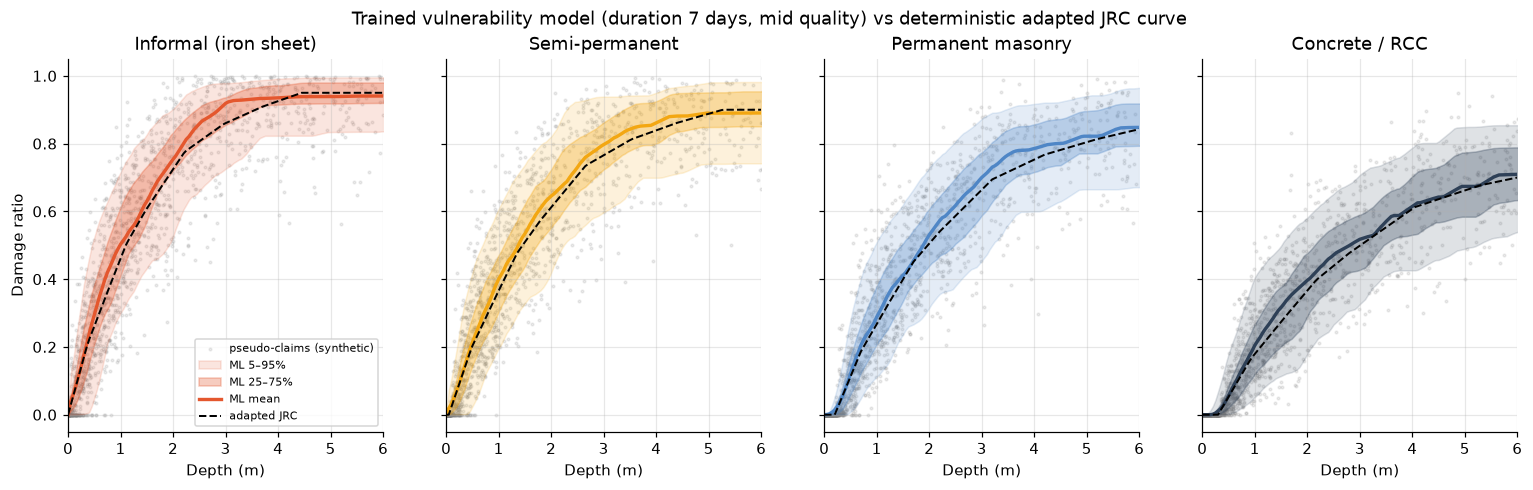

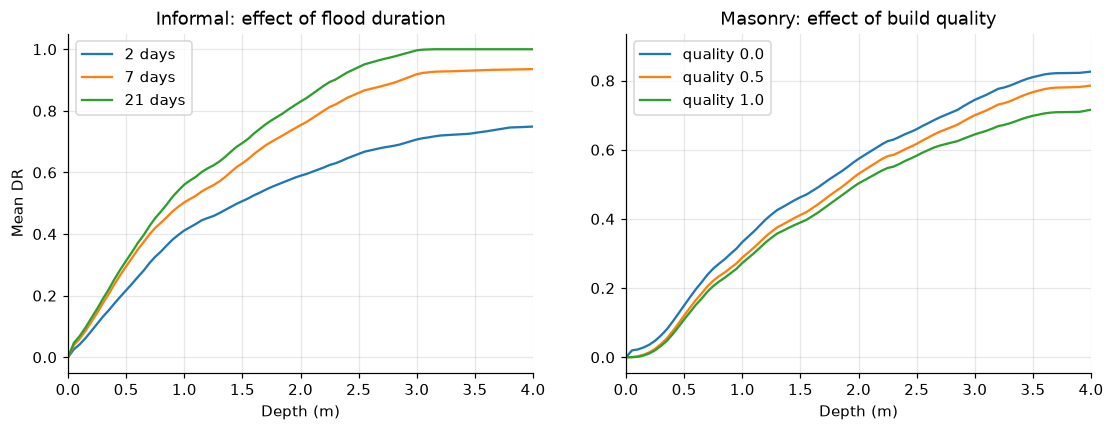

In [17]:
DEPTH_GRID = np.round(np.arange(0, 8.0001, 0.05), 4)
Q_GRID = np.array([0.0, 0.5, 1.0])
DUR_GRID = np.array([2.0, 7.0, 21.0])
STATS = ["mean", "q05", "q25", "q50", "q75", "q95"]

def predict_grid():
    tbl = {}
    for cls in CLASSES:
        arr = np.zeros((len(STATS), len(DUR_GRID), len(Q_GRID), len(DEPTH_GRID)))
        for di, dur in enumerate(DUR_GRID):
            for qi, q in enumerate(Q_GRID):
                X = np.column_stack([np.full(len(DEPTH_GRID), CLASS_CODE[cls]), DEPTH_GRID,
                                     np.full(len(DEPTH_GRID), dur), np.full(len(DEPTH_GRID), q)])
                preds = [mean_model.predict(X)] + [q_models[qq].predict(X) for qq in QUANTILES]
                P = np.clip(np.vstack(preds), 0, 1)
                # tree ensembles are piecewise constant: a ±0.15 m centred moving average removes
                # split-point steps without moving the curve (window << 0.5 m JRC knot spacing)
                k = 3
                Ppad = np.pad(P, ((0, 0), (k, k)), mode="edge")
                P = np.stack([np.convolve(row, np.ones(2 * k + 1) / (2 * k + 1), mode="valid") for row in Ppad])
                P[1:] = np.sort(P[1:], axis=0)
                P = np.maximum.accumulate(P, axis=1)       # monotone in depth
                P[:, 0] = 0.0                              # no water, no damage
                arr[:, di, qi, :] = P
        tbl[cls] = arr
    return tbl

VTABLE = predict_grid()
JRC_TABLE = {cls: adapted_dr(DEPTH_GRID, cls) for cls in CLASSES}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4), sharey=True)
for ax, cls in zip(axes, CLASSES):
    A = VTABLE[cls][:, 1, 1, :]
    s = claims[(claims.housing_class == cls)].sample(1500, random_state=1)
    ax.scatter(s.depth_m, s.damage_ratio, s=3, alpha=0.15, color="grey", label="pseudo-claims (synthetic)")
    ax.fill_between(DEPTH_GRID, A[1], A[5], color=CLASS_COLOR[cls], alpha=0.15, label="ML 5–95%")
    ax.fill_between(DEPTH_GRID, A[2], A[4], color=CLASS_COLOR[cls], alpha=0.3, label="ML 25–75%")
    ax.plot(DEPTH_GRID, A[0], color=CLASS_COLOR[cls], lw=2.2, label="ML mean")
    ax.plot(DEPTH_GRID, JRC_TABLE[cls], "k--", lw=1.3, label="adapted JRC")
    ax.set(title=CLASS_LABEL[cls], xlabel="Depth (m)", xlim=(0, 6))
axes[0].set_ylabel("Damage ratio"); axes[0].legend(fontsize=7, loc="lower right")
fig.suptitle("Trained vulnerability model (duration 7 days, mid quality) vs deterministic adapted JRC curve")
fig.savefig(FIG / "vuln_ml_vs_jrc.png", bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for di, dur in enumerate(DUR_GRID):
    axes[0].plot(DEPTH_GRID, VTABLE["informal_iron_sheet"][0, di, 1], label=f"{dur:.0f} days")
for qi, q in enumerate(Q_GRID):
    axes[1].plot(DEPTH_GRID, VTABLE["permanent_masonry"][0, 1, qi], label=f"quality {q:.1f}")
axes[0].set(title="Informal: effect of flood duration", xlabel="Depth (m)", ylabel="Mean DR", xlim=(0, 4)); axes[0].legend()
axes[1].set(title="Masonry: effect of build quality", xlabel="Depth (m)", xlim=(0, 4)); axes[1].legend()
fig.savefig(FIG / "vuln_effects.png", bbox_inches="tight"); plt.show()

### 3.6 The vulnerability lookup used by the financial engine

`vuln_lookup` interpolates linearly in depth and in quality, and selects the duration scenario. `model="jrc"` returns the
deterministic adapted curve (ignores quality/duration) so the effect of the ML layer can be isolated. An optional
`plinth_extra_m` (e.g. "house raised 0.5 m on stilts", extracted by the LLM ingestion feature) reduces effective depth.

In [18]:
DUR_INDEX = {2: 0, 7: 1, 21: 2}

def vuln_lookup_vec(cls, depth, quality, plinth_extra=0.0, model="ml", duration=7, stats=("mean",)):
    # depth & quality: equal-shape arrays. Bilinear in (quality, depth) on the exported grid, flat beyond 8 m.
    depth = np.clip(np.asarray(depth, float) - plinth_extra, 0, None)
    if model == "jrc":
        v = np.interp(depth, DEPTH_GRID, JRC_TABLE[cls]); return {s: v for s in stats}
    A = VTABLE[cls][:, DUR_INDEX[int(duration)]]
    qx = np.clip(np.broadcast_to(np.asarray(quality, float), depth.shape), 0, 1) * 2
    q0 = np.minimum(np.floor(qx).astype(int), 1); wq = qx - q0
    x = np.clip(depth, 0, DEPTH_GRID[-1]) / 0.05
    i0 = np.minimum(np.floor(x).astype(int), len(DEPTH_GRID) - 2); w = x - i0
    out = {}
    for s in stats:
        M = A[STATS.index(s)]                                # (q, depth)
        lo = M[q0, i0] * (1 - w) + M[q0, i0 + 1] * w
        hi = M[q0 + 1, i0] * (1 - w) + M[q0 + 1, i0 + 1] * w
        out[s] = np.where(depth > 0, lo * (1 - wq) + hi * wq, 0.0)
    return out

# sanity check against a direct model prediction at a grid point
_X = np.array([[CLASS_CODE["semi_permanent"], 1.0, 7.0, 0.5]])
assert abs(vuln_lookup_vec("semi_permanent", np.array([1.0]), np.array([0.5]))["mean"][0]
           - np.clip(mean_model.predict(_X), 0, 1)[0]) < 0.02
print("ML mean DR for a semi-permanent house (q=0.5, 7 days) at 0.5/1/2 m:",
      np.round(vuln_lookup_vec("semi_permanent", np.array([0.5, 1, 2]), 0.5)["mean"], 3))

ML mean DR for a semi-permanent house (q=0.5, 7 days) at 0.5/1/2 m: [0.213 0.4   0.645]


## 4. Financial engine

### 4.1 Building-level scenario losses

For every building and every return period: depth → damage ratio → × TIV = ground-up loss. Summing buildings gives the
portfolio loss of that scenario. Using each JRC map as one portfolio-wide event assumes **full spatial correlation** along
the river reach — reasonable for a single basin where one flood wave inundates the whole floodplain (assumption A-FIN-1).

In [19]:
def damage_matrix(df, depth_cols, model="ml", duration=7):
    DR = np.zeros((len(df), len(depth_cols)))
    for cls in CLASSES:
        m = (df.housing_class == cls).to_numpy()
        if not m.any(): continue
        for j, col in enumerate(depth_cols):
            DR[m, j] = vuln_lookup_vec(cls, df.loc[m, col].to_numpy(), df.loc[m, "quality"].to_numpy(),
                                       df.loc[m, "plinth_extra_m"].to_numpy(), model, duration)["mean"]
    return DR

PT_COLS = [f"d{rp}" for rp in RPS]; BL_COLS = [f"db{rp}" for rp in RPS]
DR_ml = damage_matrix(expo, PT_COLS, "ml")
DR_jrc = damage_matrix(expo, PT_COLS, "jrc")
TIV = expo.tiv_kes.to_numpy()
L_ml, L_jrc = DR_ml * TIV[:, None], DR_jrc * TIV[:, None]

scen = pd.DataFrame({
    "return_period": RPS, "AEP": 1 / RPS,
    "gross_loss_ML_KES_M": L_ml.sum(0) / 1e6,
    "gross_loss_JRC_baseline_KES_M": L_jrc.sum(0) / 1e6,
    "ML_vs_baseline_pct": 100 * (L_ml.sum(0) / L_jrc.sum(0) - 1),
    "loss_pct_of_TIV_ML": 100 * L_ml.sum(0) / TIV.sum(),
    "buildings_with_loss": (L_ml > 0).sum(0),
})
scen

,return_period,AEP,gross_loss_ML_KES_M,gross_loss_JRC_baseline_KES_M,ML_vs_baseline_pct,loss_pct_of_TIV_ML,buildings_with_loss
0,10,0.1000,24.1500,22.8174,5.8406,1.0621,46
1,20,0.0500,26.7245,25.2783,5.7210,1.1754,48
2,50,0.0200,29.8544,28.1420,6.0849,1.3130,48
3,100,0.0100,32.1520,30.2454,6.3036,1.4141,48
4,200,0.0050,34.3193,32.2167,6.5264,1.5094,48
5,500,0.0020,37.0055,34.7260,6.5642,1.6275,48


,informal_iron_sheet,semi_permanent,permanent_masonry,concrete_rcc
RP10,0.8700,0.7900,12.5700,9.9200
RP20,0.9700,1.0100,13.5900,11.1600
RP50,1.0700,1.3100,14.8500,12.6200
RP100,1.1500,1.4600,15.8900,13.6500
RP200,1.2100,1.6000,16.8700,14.6400
RP500,1.2800,1.7400,18.1600,15.8300


,buildings,TIV_KES_M,wet_at_RP100,TIV_wet_RP100_KES_M,RP100_loss_KES_M,RP100_loss_pct_of_class_TIV,mean_DR_of_wet_buildings_RP100
informal_iron_sheet,168,18.8300,22,2.8650,1.1480,6.0990,0.4150
semi_permanent,154,76.5350,9,4.6600,1.4590,1.9060,0.3270
permanent_masonry,124,672.7550,14,71.5600,15.8920,2.3620,0.2070
concrete_rcc,54,"1,505.5900",3,88.5750,13.6530,0.9070,0.1650


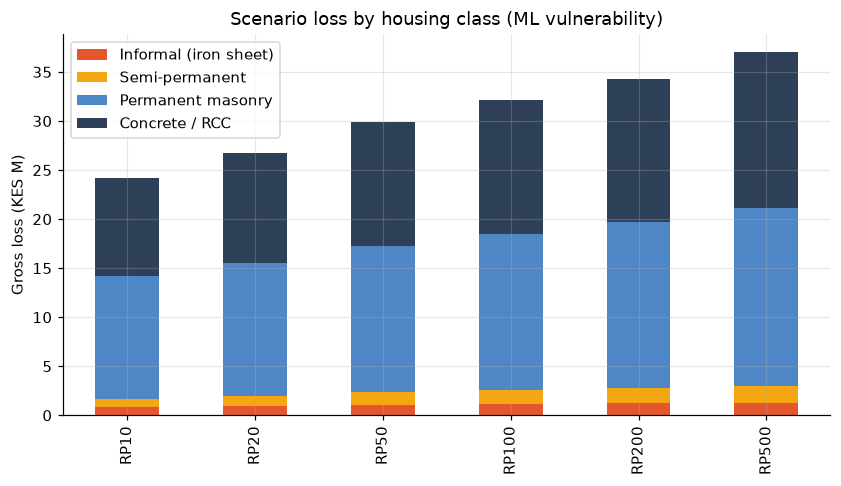

In [20]:
by_class = pd.DataFrame({cls: L_ml[(expo.housing_class == cls).to_numpy()].sum(0) / 1e6 for cls in CLASSES},
                        index=[f"RP{r}" for r in RPS])
display(by_class.round(2))
cls_summary = pd.DataFrame({
    "buildings": expo.groupby("housing_class").size(),
    "TIV_KES_M": expo.groupby("housing_class").tiv_kes.sum() / 1e6,
    "wet_at_RP100": expo.assign(w=expo.d100 > 0).groupby("housing_class").w.sum(),
    "TIV_wet_RP100_KES_M": expo.assign(v=np.where(expo.d100 > 0, expo.tiv_kes, 0)).groupby("housing_class").v.sum() / 1e6,
    "RP100_loss_KES_M": by_class.loc["RP100"],
}).reindex(CLASSES)
cls_summary["RP100_loss_pct_of_class_TIV"] = 100 * cls_summary.RP100_loss_KES_M / cls_summary.TIV_KES_M
cls_summary["mean_DR_of_wet_buildings_RP100"] = [
    DR_ml[((expo.housing_class == c) & (expo.d100 > 0)).to_numpy(), 3].mean() for c in CLASSES]
display(cls_summary.round(3))

ax = by_class.plot(kind="bar", stacked=True, color=[CLASS_COLOR[c] for c in CLASSES], figsize=(9, 4.5))
ax.set(ylabel="Gross loss (KES M)", title="Scenario loss by housing class (ML vulnerability)")
ax.legend([CLASS_LABEL[c] for c in CLASSES]); plt.savefig(FIG / "loss_by_class.png", bbox_inches="tight"); plt.show()

### 4.2 Hazard between and beyond the published return periods

The EP curve, AAL and Monte Carlo need depth at *any* return period. Assumptions (A-HAZ-2/3):

* At RP ≤ 2 years the river stays within its banks → depth 0 (bank-full discharge is commonly placed at ~1.5–2 years).
* Between published return periods depth is interpolated **linearly in ln(RP)** (the Gumbel-type behaviour of flood stage).
* Beyond RP500 depth is extrapolated with the RP200→RP500 slope, capped at RP 10,000.

In [21]:
LN_KNOTS = np.log(np.r_[2, RPS])                  # 7 knots: RP2 (dry), RP10 .. RP500
LN_MAX = np.log(10_000)

def depth_at_rp(D6, rp):
    # D6: (n, 6) depths at RPS. rp: scalar or (y,) array. Returns (n,) or (y, n).
    Y = np.column_stack([np.zeros(len(D6)), D6])    # (n, 7)
    lr = np.clip(np.log(np.atleast_1d(np.asarray(rp, float))), np.log(2), LN_MAX)
    k = np.clip(np.searchsorted(LN_KNOTS, lr, side="right") - 1, 0, 5)
    w = (lr - LN_KNOTS[k]) / (LN_KNOTS[k + 1] - LN_KNOTS[k])
    out = Y[:, k].T * (1 - w)[:, None] + Y[:, k + 1].T * w[:, None]   # (y, n); w>1 extrapolates beyond RP500
    slope_ok = (Y[:, 6] >= Y[:, 5])[None, :]
    out = np.where((w[:, None] > 1) & ~slope_ok, Y[:, 6][None, :], out)
    out = np.maximum(out, 0)
    return out[0] if np.ndim(rp) == 0 else out

assert np.allclose(depth_at_rp(D_point, 100), D_point[:, 3])
print("Depth at RP250 for the 5 deepest buildings:", np.round(np.sort(depth_at_rp(D_point, 250))[-5:], 2))

Depth at RP250 for the 5 deepest buildings: [1.95 3.32 3.52 3.77 4.47]


### 4.3 Insurance and reinsurance terms (illustrative — assumption A-FIN-2)

* **Policy terms per building:** deductible = 2 % of TIV, limit = 100 % of TIV. Insured loss = min(max(ground-up − deductible, 0), limit).
* **Reinsurance (cedant view):** optional quota share (default 0 %), then a **Cat Excess-of-Loss layer** applied to the
  event's aggregate insured loss: default KES 20 M xs KES 20 M, sized so it attaches around the 1-in-10 to 1-in-20 year
  level of this portfolio. These are illustrative terms to show the mechanics; treaty structuring is out of scope for the
  challenge and every term is editable in the dashboard.

In [22]:
TERMS = dict(deductible_pct=0.02, limit_pct=1.00, qs_cession=0.0, xl_retention=20e6, xl_limit=20e6)

def apply_policy(gu, tiv, t=TERMS):
    return np.clip(gu - t["deductible_pct"] * tiv, 0, t["limit_pct"] * tiv)

def apply_reinsurance(event_insured, t=TERMS):
    qs = t["qs_cession"] * event_insured
    after_qs = event_insured - qs
    xl = np.clip(after_qs - t["xl_retention"], 0, t["xl_limit"])
    return dict(insured=event_insured, qs_ceded=qs, xl_ceded=xl, net=after_qs - xl)

def portfolio_event_loss(df, rp, model="ml", duration=7, mode="point", t=TERMS):
    cols = PT_COLS if mode == "point" else BL_COLS
    d = depth_at_rp(df[cols].to_numpy(), rp)
    gu = np.zeros(len(df))
    for cls in CLASSES:
        m = (df.housing_class == cls).to_numpy()
        if m.any():
            gu[m] = vuln_lookup_vec(cls, d[m], df.quality.to_numpy()[m], df.plinth_extra_m.to_numpy()[m],
                                    model, duration)["mean"] * df.tiv_kes.to_numpy()[m]
    ins = apply_policy(gu, df.tiv_kes.to_numpy(), t)
    r = apply_reinsurance(ins.sum(), t)
    return dict(gross=gu.sum(), **r, gu_vec=gu)

KEY_RPS = [10, 20, 50, 100, 200, 250, 500, 1000]
fin = []
for rp in KEY_RPS:
    r = portfolio_event_loss(expo, rp)
    fin.append(dict(return_period=rp, interpolated=rp not in RPS, AEP=1 / rp, gross_M=r["gross"] / 1e6,
                    insured_M=r["insured"] / 1e6, xl_recovery_M=r["xl_ceded"] / 1e6, net_retained_M=r["net"] / 1e6))
fin = pd.DataFrame(fin)
fin

,return_period,interpolated,AEP,gross_M,insured_M,xl_recovery_M,net_retained_M
0,10,False,0.1000,24.1500,21.0294,1.0294,20.0000
1,20,False,0.0500,26.7245,23.4998,3.4998,20.0000
2,50,False,0.0200,29.8544,26.5934,6.5934,20.0000
3,100,False,0.0100,32.1520,28.8362,8.8362,20.0000
4,200,False,0.0050,34.3193,30.9991,10.9991,20.0000
5,250,True,0.0040,34.9743,31.6503,11.6503,20.0000
6,500,False,0.0020,37.0055,33.6593,13.6593,20.0000
7,1000,True,0.0010,39.0554,35.7022,15.7022,20.0000


### 4.4 EP curve and Average Annual Loss (deterministic)

AAL is the integral of the loss curve over annual exceedance probability, $\mathrm{AAL} = \int_0^{1} L(p)\,dp$, evaluated on
400 log-spaced probabilities between 10⁻⁴ and 0.5 (no loss below RP2), plus the tail $L(10^{-4})\times10^{-4}$.

AAL gross (ML):        KES 5.8 M  = 2.56‰ of TIV
AAL gross (JRC base):  KES 5.4 M
AAL insured (ML):      KES 4.9 M   |  AAL net of XL: KES 4.5 M


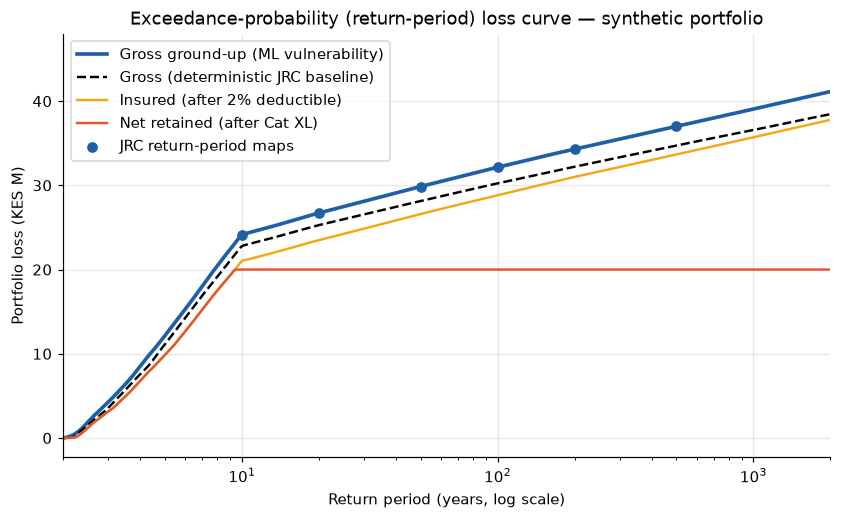

In [23]:
P_GRID = np.logspace(np.log10(1e-4), np.log10(0.5), 400)

def ep_curve(df, model="ml", duration=7, mode="point", t=TERMS):
    rows = [portfolio_event_loss(df, 1 / p, model, duration, mode, t) for p in P_GRID]
    G = np.array([r["gross"] for r in rows]); I = np.array([r["insured"] for r in rows]); N = np.array([r["net"] for r in rows])
    aal = lambda L: np.trapezoid(L, P_GRID) + L[0] * P_GRID[0]
    return dict(p=P_GRID, gross=G, insured=I, net=N, aal_gross=aal(G), aal_insured=aal(I), aal_net=aal(N))

EP = ep_curve(expo)
EP_JRC = ep_curve(expo, model="jrc")
print(f"AAL gross (ML):        {kes_m(EP['aal_gross'])}  = {1e3*EP['aal_gross']/TIV.sum():.2f}‰ of TIV")
print(f"AAL gross (JRC base):  {kes_m(EP_JRC['aal_gross'])}")
print(f"AAL insured (ML):      {kes_m(EP['aal_insured'])}   |  AAL net of XL: {kes_m(EP['aal_net'])}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(1 / EP["p"], EP["gross"] / 1e6, lw=2.4, color="#1f5fa8", label="Gross ground-up (ML vulnerability)")
ax.semilogx(1 / EP_JRC["p"], EP_JRC["gross"] / 1e6, lw=1.6, ls="--", color="k", label="Gross (deterministic JRC baseline)")
ax.semilogx(1 / EP["p"], EP["insured"] / 1e6, lw=1.6, color="#f3a712", label="Insured (after 2% deductible)")
ax.semilogx(1 / EP["p"], EP["net"] / 1e6, lw=1.6, color="#e4572e", label="Net retained (after Cat XL)")
ax.scatter(RPS, L_ml.sum(0) / 1e6, color="#1f5fa8", zorder=5, label="JRC return-period maps")
ax.set(xlabel="Return period (years, log scale)", ylabel="Portfolio loss (KES M)", xlim=(2, 2000),
       title="Exceedance-probability (return-period) loss curve — synthetic portfolio")
ax.legend(); fig.savefig(FIG / "ep_curve.png", bbox_inches="tight"); plt.show()

### 4.5 Monte Carlo year-loss table with secondary uncertainty

The deterministic curve uses the *mean* damage ratio. Real losses scatter around it. The stochastic engine simulates
**50,000 years**:

1. Each year draws one annual-maximum flood severity $p \sim U(0,1)$, i.e. return period $1/p$ (one dominant river flood
   per season — assumption A-FIN-3).
2. Every building's depth is read from the hazard curve at that return period.
3. Damage is sampled from the ML quantile heads (piecewise-linear inverse CDF through the 5/25/50/75/95 % points),
   rescaled so its mean equals the ML mean head (*mean-preserving* — AAL is unchanged in expectation).
4. Damage uncertainty is **correlated across buildings in the same event** through a one-factor Gaussian copula with
   ρ = 0.3 (same flood wave, same duration, same debris load) — assumption A-FIN-4.
5. Policy terms and the Cat XL are applied per simulated year.

The output is a year-loss table from which we read the OEP curve, AAL, standard deviation and Tail-VaR.

In [24]:
U_KNOTS = np.array([0.0, 0.05, 0.25, 0.50, 0.75, 0.95, 1.0])

def quantile_knots(qd, cap):
    # qd: dict of q05..q95 arrays -> (…, 7) knot values for the inverse CDF, plus its mean
    q05, q25, q50, q75, q95 = (qd[k] for k in ["q05", "q25", "q50", "q75", "q95"])
    v0 = np.maximum(0, q05 - 0.25 * (q25 - q05))
    v1 = np.minimum(cap, q95 + 0.25 * (q95 - q75))
    V = np.stack([v0, q05, q25, q50, q75, q95, np.maximum(v1, q95)], axis=-1)
    qbar = (np.diff(U_KNOTS) * (V[..., 1:] + V[..., :-1]) / 2).sum(-1)
    return V, qbar

def inv_cdf(V, u):
    k = np.clip(np.searchsorted(U_KNOTS, u, side="right") - 1, 0, 5)
    w = (u - U_KNOTS[k]) / (U_KNOTS[k + 1] - U_KNOTS[k])
    lo = np.take_along_axis(V, k[..., None], -1)[..., 0]; hi = np.take_along_axis(V, (k + 1)[..., None], -1)[..., 0]
    return lo + w * (hi - lo)

def simulate(df, n_years=50_000, rho=0.3, model="ml", duration=7, mode="point", t=TERMS, seed=SEED):
    g = np.random.default_rng(seed)
    cols = PT_COLS if mode == "point" else BL_COLS
    D6 = df[cols].to_numpy()
    at_risk = depth_at_rp(D6, 10_000) > 0
    sub = df[at_risk].reset_index(drop=True); D6 = D6[at_risk]
    tiv = sub.tiv_kes.to_numpy()
    p = g.random(n_years)
    flood = p < 0.5
    rp = 1 / np.maximum(p[flood], 1e-12)
    depth = depth_at_rp(D6, rp)                                    # (y, n)
    Z = g.standard_normal(len(rp))[:, None]
    E = g.standard_normal(depth.shape)
    u = norm.cdf(np.sqrt(rho) * Z + np.sqrt(1 - rho) * E)
    dr = np.zeros_like(depth)
    for cls in CLASSES:
        m = (sub.housing_class == cls).to_numpy()
        if not m.any(): continue
        dd = depth[:, m]; qq = np.broadcast_to(sub.quality.to_numpy()[m], dd.shape)
        pl = np.broadcast_to(sub.plinth_extra_m.to_numpy()[m], dd.shape)
        if model == "jrc":
            dr[:, m] = vuln_lookup_vec(cls, dd - pl, qq, 0.0, "jrc")["mean"]; continue
        st = vuln_lookup_vec(cls, dd - pl, qq, 0.0, "ml", duration, stats=tuple(STATS))
        V, qbar = quantile_knots(st, CLASS_PARAMS.loc[cls, "max_damage"])
        draw = inv_cdf(V, u[:, m])
        dr[:, m] = np.where(qbar > 1e-9, np.clip(st["mean"] * draw / np.maximum(qbar, 1e-9), 0, 1), st["mean"])
    gu = dr * tiv[None, :]
    ins = np.clip(gu - t["deductible_pct"] * tiv, 0, t["limit_pct"] * tiv).sum(1)
    re = apply_reinsurance(ins, t)
    G = np.zeros(n_years); I = np.zeros(n_years); N = np.zeros(n_years); R = np.ones(n_years)
    G[flood], I[flood], N[flood], R[flood] = gu.sum(1), ins, re["net"], rp
    return pd.DataFrame(dict(year=np.arange(n_years), event_rp=np.where(flood, R, np.nan), gross=G, insured=I, net=N))

def oep_stats(ylt, col="gross", rps=(10, 20, 50, 100, 200, 250, 500, 1000)):
    L = np.sort(ylt[col].to_numpy())[::-1]; n = len(L)
    out = {f"RP{r}": L[int(n / r) - 1] for r in rps}
    out["AAL"] = L.mean(); out["StdDev"] = L.std()
    k = int(n * 0.01); out["TVaR_1pct"] = L[:k].mean()
    return out

ylt = simulate(expo)
ylt.to_csv(OUT / "year_loss_table.csv", index=False)
mc = pd.DataFrame({c: oep_stats(ylt, c) for c in ["gross", "insured", "net"]}) / 1e6
display(mc.round(2))
print(f"Deterministic AAL (gross) {EP['aal_gross']/1e6:.2f} M vs Monte Carlo AAL {ylt.gross.mean()/1e6:.2f} M "
      f"(difference {100*(ylt.gross.mean()/EP['aal_gross']-1):+.2f}% — sampling noise; the sampler is mean-preserving)")

,gross,insured,net
RP10,21.3900,18.6500,18.6500
RP20,28.2600,25.2600,20.0000
RP50,34.5500,31.4500,20.0000
RP100,38.7000,35.4700,20.0000
RP200,42.4900,39.2500,20.0000
RP250,43.2200,39.9500,20.0000
RP500,46.0900,42.7600,22.7600
RP1000,47.8800,44.5500,24.5500
AAL,5.8500,5.0600,4.4100
StdDev,9.6900,8.6800,6.8800


Deterministic AAL (gross) 5.81 M vs Monte Carlo AAL 5.85 M (difference +0.65% — sampling noise; the sampler is mean-preserving)


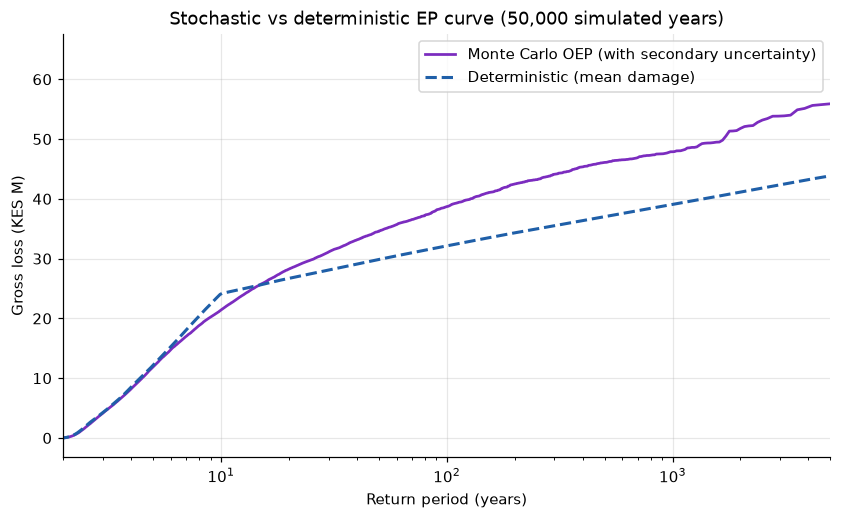

In [25]:
L = np.sort(ylt.gross.to_numpy())[::-1]; rp_emp = len(L) / np.arange(1, len(L) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(rp_emp, L / 1e6, color="#7b2cbf", lw=1.8, label="Monte Carlo OEP (with secondary uncertainty)")
ax.semilogx(1 / EP["p"], EP["gross"] / 1e6, color="#1f5fa8", lw=2, ls="--", label="Deterministic (mean damage)")
ax.set(xlim=(2, 5000), xlabel="Return period (years)", ylabel="Gross loss (KES M)",
       title="Stochastic vs deterministic EP curve (50,000 simulated years)")
ax.legend(); fig.savefig(FIG / "ep_mc_vs_det.png", bbox_inches="tight"); plt.show()

**Reading the two curves.** Both have the same AAL, but the stochastic curve is *lower* at the frequent end and *higher* in
the tail. Because damage uncertainty is partly shared across buildings in the same flood (ρ = 0.3), a bad year is bad for
many buildings at once — so the 1-in-100 and 1-in-200 OEP losses sit above the deterministic "mean-damage" scenario losses.
This is the number a reinsurance buyer should use for the tail; the deterministic curve is the transparent explanation.

### 4.6 Sensitivity — which assumptions move the answer?

Each row changes **one** assumption from the base case (ML vulnerability, point hazard sampling, 7-day duration, ρ = 0.3)
and reports the gross RP100 scenario loss and the AAL. This is the honest answer to "how much should I trust the number?".

In [26]:
def det_summary(df, **kw):
    e = ep_curve(df, **{k: v for k, v in kw.items() if k in ("model", "duration", "mode")})
    return portfolio_event_loss(df, 100, **{k: v for k, v in kw.items() if k in ("model", "duration", "mode")})["gross"], e["aal_gross"]

base_rp100, base_aal = scen.loc[3, "gross_loss_ML_KES_M"] * 1e6, EP["aal_gross"]
cases = [("Vulnerability: deterministic JRC baseline (no ML)", dict(model="jrc")),
         ("Hazard sampling: bilinear (location uncertainty)", dict(mode="bilinear")),
         ("Flood duration: short (2 days)", dict(duration=2)),
         ("Flood duration: prolonged (21 days)", dict(duration=21))]
sens = [dict(case="BASE: ML, point, 7 days", RP100_gross_M=base_rp100 / 1e6, AAL_gross_M=base_aal / 1e6)]
for name, kw in cases:
    r100, aal = det_summary(expo, **kw)
    sens.append(dict(case=name, RP100_gross_M=r100 / 1e6, AAL_gross_M=aal / 1e6))
quality_flat = expo.assign(quality=0.5)
r100, aal = det_summary(quality_flat)
sens.append(dict(case="Ignore build quality (all q = 0.5)", RP100_gross_M=r100 / 1e6, AAL_gross_M=aal / 1e6))
sens = pd.DataFrame(sens)
sens["RP100_vs_base_pct"] = 100 * (sens.RP100_gross_M / (base_rp100 / 1e6) - 1)
sens["AAL_vs_base_pct"] = 100 * (sens.AAL_gross_M / (base_aal / 1e6) - 1)
display(sens.round(2))

sens_mc = []
for rho in (0.0, 0.3, 0.6):
    y = ylt if rho == 0.3 else simulate(expo, n_years=50_000, rho=rho)
    s_ = oep_stats(y)
    sens_mc.append(dict(rho=rho, OEP_RP100_M=s_["RP100"] / 1e6, OEP_RP200_M=s_["RP200"] / 1e6,
                        TVaR_1pct_M=s_["TVaR_1pct"] / 1e6, AAL_M=s_["AAL"] / 1e6))
sens_mc = pd.DataFrame(sens_mc)
print("Monte Carlo: effect of correlating damage uncertainty across buildings (AAL is unaffected, the tail is not)")
sens_mc.round(2)

,case,RP100_gross_M,AAL_gross_M,RP100_vs_base_pct,AAL_vs_base_pct
0,"BASE: ML, point, 7 days",32.1500,5.8100,0.0000,0.0000
1,Vulnerability: deterministic JRC baseline (no ML),30.2500,5.3700,-5.9300,-7.5700
2,Hazard sampling: bilinear (location uncertainty),35.3700,6.1100,10.0200,5.0900
3,Flood duration: short (2 days),29.8200,5.2600,-7.2700,-9.5500
4,Flood duration: prolonged (21 days),34.6100,6.4000,7.6300,10.1000
5,Ignore build quality (all q = 0.5),32.8500,5.9100,2.1600,1.7300


Monte Carlo: effect of correlating damage uncertainty across buildings (AAL is unaffected, the tail is not)


,rho,OEP_RP100_M,OEP_RP200_M,TVaR_1pct_M,AAL_M
0,0.0000,34.7000,37.1100,38.2400,5.8500
1,0.3000,38.7000,42.4900,43.3100,5.8500
2,0.6000,41.6600,46.1400,47.0300,5.8500


## 5. Accumulation & top risks (portfolio-manager view)

Each synthetic building is labelled with its nearest named place (approximate gazetteer coordinates, ±2–3 km — assumption
A-EXP-3) so concentration can be discussed in words a county officer or exposure manager would use.

In [27]:
GAZETTEER = [  # approximate town/village centroids (decimal degrees, WGS84) — for labelling & LLM geocoding only
    ("Port Victoria", 0.0950, 33.9750), ("Budalangi", 0.1300, 34.0200), ("Rwambwa", 0.1450, 34.0700),
    ("Sio Port", 0.2200, 34.0200), ("Usenge", -0.0700, 34.0600), ("Funyula", 0.2700, 34.1000),
    ("Busia", 0.4608, 34.1115), ("Nambale", 0.4540, 34.2550), ("Bumala", 0.3000, 34.2000),
    ("Ugunja", 0.1830, 34.2900), ("Siaya", 0.0612, 34.2881), ("Butere", 0.2069, 34.4903),
    ("Mumias", 0.3356, 34.4886), ("Malaba", 0.6360, 34.2800), ("Bungoma", 0.5635, 34.5606),
    ("Kakamega", 0.2827, 34.7519), ("Webuye", 0.6072, 34.7697), ("Kimilili", 0.7870, 34.7200),
    ("Kitale", 1.0157, 35.0062), ("Eldoret (west)", 0.5143, 35.2698), ("Kapsabet", 0.2040, 35.1050),
    ("Malava", 0.4450, 34.8530), ("Chwele", 0.7350, 34.6200), ("Amagoro", 0.6310, 34.3240),
]
gaz = pd.DataFrame(GAZETTEER, columns=["name", "lat", "lon"])
pr, pc = rowcol(T, gaz.lon.values, gaz.lat.values)
gaz["inside_grid"] = (np.array(pr) >= 0) & (np.array(pr) < NROWS) & (np.array(pc) >= 0) & (np.array(pc) < NCOLS)
dist10 = distance_transform_edt(~(H[0] > 0))
gaz["km_to_nearest_RP10_flood_cell"] = [dist10[r, c] * km_per_cell if ok else np.nan
                                        for r, c, ok in zip(pr, pc, gaz.inside_grid)]

def nearest_place(lat, lon):
    d = (gaz.lat.values[None, :] - np.asarray(lat)[:, None]) ** 2 + \
        ((gaz.lon.values[None, :] - np.asarray(lon)[:, None]) * np.cos(np.radians(0.5))) ** 2
    return gaz.name.values[d.argmin(1)], np.sqrt(d.min(1)) * 111.32

expo["area"], expo["area_km"] = nearest_place(expo.lat.values, expo.lon.values)
display(gaz.sort_values("km_to_nearest_RP10_flood_cell").round(2))

,name,lat,lon,inside_grid,km_to_nearest_RP10_flood_cell
1,Budalangi,0.1300,34.0200,True,0.0000
4,Usenge,-0.0700,34.0600,True,0.9300
0,Port Victoria,0.1000,33.9800,True,1.3100
2,Rwambwa,0.1400,34.0700,True,2.0700
12,Mumias,0.3400,34.4900,True,2.0700
9,Ugunja,0.1800,34.2900,True,2.6200
3,Sio Port,0.2200,34.0200,True,2.9300
16,Webuye,0.6100,34.7700,True,3.3400
8,Bumala,0.3000,34.2000,True,12.3800
11,Butere,0.2100,34.4900,True,12.4800


In [28]:
expo["loss_rp100"] = L_ml[:, 3]
acc = expo.groupby("area").agg(
    buildings=("loc_id", "size"), TIV_M=("tiv_kes", lambda s: s.sum() / 1e6),
    wet_RP100=("d100", lambda s: int((s > 0).sum())),
    TIV_in_RP100_footprint_M=("tiv_kes", lambda s: s[expo.loc[s.index, "d100"] > 0].sum() / 1e6),
    TIV_within_2km_M=("tiv_kes", lambda s: s[expo.loc[s.index, "dist_rp100_km"] <= 2].sum() / 1e6),
    RP100_loss_M=("loss_rp100", lambda s: s.sum() / 1e6),
).sort_values("RP100_loss_M", ascending=False)
acc["share_of_portfolio_RP100_loss_pct"] = 100 * acc.RP100_loss_M / acc.RP100_loss_M.sum()
display(acc.head(12).round(2))
print(f"Portfolio TIV inside RP100 footprint: {kes_m(expo.tiv_kes[expo.d100 > 0].sum())} "
      f"({100*expo.tiv_kes[expo.d100 > 0].sum()/TIV.sum():.1f}% of TIV); within 2 km: "
      f"{kes_m(expo.tiv_kes[expo.dist_rp100_km <= 2].sum())}")

top = expo.assign(dr_rp100=DR_ml[:, 3]).sort_values("loss_rp100", ascending=False).head(15)[
    ["loc_id", "area", "housing_class", "tiv_kes", "d10", "d100", "d500", "dr_rp100", "loss_rp100"]]
top

,buildings,TIV_M,wet_RP100,TIV_in_RP100_footprint_M,TIV_within_2km_M,RP100_loss_M,share_of_portfolio_RP100_loss_pct
area,,,,,,,
Port Victoria,13,91.6900,12,91.6000,91.6000,19.8100,61.6200
Usenge,24,83.3300,16,44.2100,58.1500,5.8900,18.3100
Busia,30,210.1400,2,6.4000,20.0200,4.2700,13.2800
Siaya,23,128.3500,7,8.2200,8.2200,1.1400,3.5500
Budalangi,4,25.6600,3,5.2000,25.6600,0.3300,1.0400
Kakamega,27,130.4400,2,0.5500,0.5500,0.2100,0.6500
Rwambwa,3,8.9000,1,2.4200,3.0600,0.2000,0.6200
Butere,16,37.2600,3,4.3600,4.3600,0.1800,0.5600
Kapsabet,55,248.6900,1,0.1400,0.1400,0.0700,0.2100


Portfolio TIV inside RP100 footprint: KES 167.7 M (7.4% of TIV); within 2 km: KES 224.0 M


,loc_id,area,housing_class,tiv_kes,d10,d100,d500,dr_rp100,loss_rp100
485,NZA-0485,Port Victoria,concrete_rcc,"21,450,000.0000",1.2500,1.3700,1.4600,0.2922,"6,267,423.8201"
377,NZA-0377,Port Victoria,concrete_rcc,"42,600,000.0000",0.6200,0.7900,0.8800,0.1352,"5,758,763.5833"
274,NZA-0274,Port Victoria,permanent_masonry,"6,295,000.0000",4.0900,4.3800,4.5400,0.7434,"4,679,697.4955"
151,NZA-0151,Busia,permanent_masonry,"5,690,000.0000",3.0200,3.5600,3.9300,0.7200,"4,096,889.4592"
209,NZA-0209,Usenge,permanent_masonry,"4,275,000.0000",1.2200,1.4100,1.5200,0.3902,"1,668,282.1420"
343,NZA-0343,Usenge,concrete_rcc,"24,525,000.0000",0.4000,0.5500,0.6400,0.0663,"1,626,614.9482"
194,NZA-0194,Port Victoria,permanent_masonry,"11,600,000.0000",0.3400,0.4700,0.5500,0.1263,"1,464,507.9983"
166,NZA-0166,Port Victoria,permanent_masonry,"4,830,000.0000",0.5500,0.7000,0.7800,0.1953,"943,192.3690"
93,NZA-0093,Usenge,permanent_masonry,"4,365,000.0000",0.4800,0.6300,0.7100,0.1731,"755,719.9766"
17,NZA-0017,Usenge,permanent_masonry,"5,355,000.0000",0.2800,0.4500,0.5500,0.1184,"634,017.3399"


## 6. Export artefacts for the web dashboard

Everything the Next.js app needs is written to `web/public/`:

| File | Content |
|---|---|
| `data/portfolio.json` | 500 buildings with corrected TIV, quality index, depths at 6 RPs (point + bilinear), area label |
| `data/hazard.json` | sparse grid of wet cells with depths at 6 RPs (to geocode & sample LLM-ingested buildings in the browser) |
| `data/vulnerability.json` | ML lookup table (mean + 5 quantiles), adapted-JRC table, class parameters, model metrics |
| `data/results.json` | the notebook's reference results (scenario table, EP, MC, sensitivity, accumulation, assumptions) used to validate the TypeScript engine |
| `data/gazetteer.json` | approximate place coordinates |
| `hazard/rp*.png`, `hazard/flood_zone.png` | transparent raster overlays for the map |

In [29]:
def r3(a): return [round(float(x), 3) for x in a]

portfolio_json = [dict(id=r.loc_id, lat=round(r.lat, 6), lon=round(r.lon, 6), cls=r.housing_class,
                       floorArea=int(r.floor_area_m2), costPerM2=int(r.cost_per_m2_kes), tiv=float(r.tiv_kes),
                       tivFile=float(r.tiv_kes_file), quality=round(r.quality, 4), plinthExtra=0.0,
                       dPoint=r3([getattr(r, c) for c in PT_COLS]), dBilinear=r3([getattr(r, c) for c in BL_COLS]),
                       distRp100Km=round(r.dist_rp100_km, 3), area=r.area, synthetic=True, origin="starter_kit")
                  for r in expo.itertuples()]

wet_cells = np.argwhere(H[-1] > 0)
hazard_json = dict(x0=X0, y0=Y0, dx=DX, dy=DY, ncols=NCOLS, nrows=NROWS, rps=RPS.tolist(),
                   source="JRC Global River Flood Hazard Maps (floodMapGL), 30 arc-sec, clipped to lower Nzoia",
                   cells=[[int(r), int(c)] + r3(H[:, r, c]) for r, c in wet_cells])

vuln_json = dict(
    depthStep=0.05, depthMax=float(DEPTH_GRID[-1]), qualityGrid=Q_GRID.tolist(), durationGrid=DUR_GRID.tolist(),
    stats=STATS, classes=CLASSES, classLabels=CLASS_LABEL, classColors=CLASS_COLOR,
    ml={cls: {s: [[r3(VTABLE[cls][k, di, qi]) for qi in range(len(Q_GRID))] for di in range(len(DUR_GRID))]
              for k, s in enumerate(STATS)} for cls in CLASSES},
    jrcAdapted={cls: r3(JRC_TABLE[cls]) for cls in CLASSES},
    jrcReference=dict(depth=JRC_DEPTH.tolist(), **{k: v.tolist() for k, v in JRC_CURVES.items()},
                      citation="Huizinga, de Moel & Szewczyk (2017), Global flood depth-damage functions, JRC EUR 28552 EN"),
    classParams=CLASS_PARAMS.reset_index().to_dict(orient="records"),
    costRanges={k: list(v) for k, v in CLASS_COST_RANGE.items()},
    training=dict(n_claims=len(claims), n_train=len(train), n_test=len(test), cv_r2_mean=float(np.mean(cv)),
                  cv_r2_std=float(np.std(cv)), coverage90=float(cov90), coverage50=float(cov50), coverage90Deep=float(cov90_deep),
                  noise_ceiling_r2=float(r2_score(yte, true_mu)),
                  metrics=metrics.to_dict(orient="records"), quantiles=quant_tbl.to_dict(orient="records"),
                  importance=importance.to_dict(orient="records"),
                  logistic={c: [float(x) for x in logit_params[c]] for c in CLASSES}),
)

def rec(df): return json.loads(df.to_json(orient="records"))

ASSUMPTIONS = [
    ("A-EXP-1", "Exposure", "TIV recomputed as floor_area × cost_per_m2 (rounded KES 5,000); file column is 10× the documented value.", "Data QA fix"),
    ("A-EXP-2", "Exposure", "Quality index = position of cost_per_m2 within the published cost band of the class.", "Assumption"),
    ("A-EXP-3", "Exposure", "Area labels and LLM geocoding use approximate town centroids (±2–3 km).", "Assumption"),
    ("A-HAZ-1", "Hazard", "Building depth = depth of the containing 925 m JRC cell (point sampling). Bilinear sampling reported as sensitivity.", "Method"),
    ("A-HAZ-2", "Hazard", "No flooding at RP ≤ 2 (in-bank flow); depth linear in ln(RP) between published maps.", "Assumption"),
    ("A-HAZ-3", "Hazard", "Beyond RP500 depth extrapolated with the RP200→500 slope, capped at RP10,000.", "Assumption"),
    ("A-VUL-1", "Vulnerability", "Shape from JRC/Huizinga (2017) Africa residential curve; global residential used as secondary source.", "Published reference"),
    ("A-VUL-2", "Vulnerability", "Class plinth heights, depth multipliers and ceilings (75–95%) are expert judgement.", "Assumption"),
    ("A-VUL-3", "Vulnerability", "ML model trained on 30,000 synthetic pseudo-claims; it reproduces the encoded assumptions plus their uncertainty, not real claims experience.", "Synthetic"),
    ("A-VUL-4", "Vulnerability", "Flood duration default 7 days (Budalangi floods often stand for 1–3 weeks).", "Assumption"),
    ("A-FIN-1", "Financial", "Each JRC map treated as one basin-wide event (full spatial correlation of hazard).", "Assumption"),
    ("A-FIN-2", "Financial", "Illustrative terms: 2% TIV deductible, 100% limit, Cat XL KES 20M xs 20M, no quota share.", "Assumption"),
    ("A-FIN-3", "Financial", "One dominant river flood per year (annual maximum); AEP = OEP.", "Assumption"),
    ("A-FIN-4", "Financial", "Secondary uncertainty correlated across buildings with a Gaussian copula, ρ = 0.3.", "Assumption"),
    ("A-FIN-5", "Financial", "Losses cover the structure only — no contents, business interruption, or demand surge.", "Scope"),
]
assump = pd.DataFrame(ASSUMPTIONS, columns=["id", "stage", "assumption", "type"])
assump.to_csv(OUT / "assumptions_register.csv", index=False)

mc_all = {c: {k: float(v) for k, v in oep_stats(ylt, c).items()} for c in ["gross", "insured", "net"]}
results_json = dict(
    generatedBy="notebooks/nzoia_flood_cat_model.ipynb", seed=SEED, terms=TERMS,
    dataQa=dict(tivFileTotal=float(expo.tiv_kes_file.sum()), tivModelTotal=float(TIV.sum()),
                tivMetadataTotal=2_273_710_000.0, tivRatioMedian=float(ratio.median())),
    hazardStats=rec(haz_stats), wetBuildings=rec(wet),
    scenario=rec(scen), byClass={c: (by_class[c] * 1e6).tolist() for c in CLASSES},
    classSummary=rec(cls_summary.reset_index()),
    financial=rec(fin),
    ep=dict(aalGross=float(EP["aal_gross"]), aalInsured=float(EP["aal_insured"]), aalNet=float(EP["aal_net"]),
            aalGrossJrc=float(EP_JRC["aal_gross"]),
            curve=[dict(rp=float(1 / p), gross=float(g), insured=float(i), net=float(n), grossJrc=float(gj))
                   for p, g, i, n, gj in zip(EP["p"][::8], EP["gross"][::8], EP["insured"][::8], EP["net"][::8], EP_JRC["gross"][::8])]),
    monteCarlo=dict(years=len(ylt), rho=0.3, stats=mc_all),
    sensitivity=rec(sens), sensitivityMc=rec(sens_mc), accumulation=rec(acc.reset_index()), topLosses=rec(top),
    assumptions=rec(assump),
)
for name, obj in [("portfolio", portfolio_json), ("hazard", hazard_json), ("vulnerability", vuln_json),
                  ("results", results_json), ("gazetteer", rec(gaz))]:
    with open(WEB_DATA / f"{name}.json", "w", encoding="utf-8") as f:
        json.dump(obj, f, separators=(",", ":"), allow_nan=False, default=float)
    print(f"wrote {name}.json  ({(WEB_DATA / f'{name}.json').stat().st_size/1024:,.0f} KB)")
expo.drop(columns=["row", "col"]).to_csv(OUT / "portfolio_with_hazard_and_losses.csv", index=False)

wrote portfolio.json  (161 KB)
wrote hazard.json  (144 KB)
wrote vulnerability.json  (205 KB)
wrote results.json  (25 KB)
wrote gazetteer.json  (3 KB)


In [30]:
# Transparent PNG overlays (north-up, same extent as the rasters). Upscaled ×4 with nearest-neighbour for crisp cells.
ramp = mcolors.LinearSegmentedColormap.from_list("d", ["#bfe3ff", "#5aa9e6", "#1f5fa8", "#0b2a5b", "#05122b"])
def to_png(arr, path, vmax=5.0):
    rgba = (ramp(np.clip(arr / vmax, 0, 1)) * 255).astype(np.uint8)
    rgba[..., 3] = np.where(arr > 0, 215, 0)
    Image.fromarray(rgba, "RGBA").resize((NCOLS * 4, NROWS * 4), Image.NEAREST).save(path)
for i, rp in enumerate(RPS):
    to_png(H[i], WEB_HAZ / f"rp{rp}.png")

# Flood-zone map: the most frequent return period at which a cell first gets wet
zone = np.zeros((NROWS, NCOLS)); zone_colors = ["#08306b", "#2171b5", "#4292c6", "#6baed6", "#9ecae1", "#c6dbef"]
rgba = np.zeros((NROWS, NCOLS, 4), np.uint8)
for i in reversed(range(6)):
    m = H[i] > 0
    c = np.array(mcolors.to_rgb(zone_colors[i])) * 255
    rgba[m, :3] = c; rgba[m, 3] = 220
Image.fromarray(rgba, "RGBA").resize((NCOLS * 4, NROWS * 4), Image.NEAREST).save(WEB_HAZ / "flood_zone.png")
print("PNG overlays written:", sorted(p.name for p in WEB_HAZ.glob("*.png")))

PNG overlays written: ['flood_zone.png', 'rp10.png', 'rp100.png', 'rp20.png', 'rp200.png', 'rp50.png', 'rp500.png']


## 7. Assumptions & limitations register

In [31]:
assump

,id,stage,assumption,type
0,A-EXP-1,Exposure,TIV recomputed as floor_area × cost_per_m2 (ro...,Data QA fix
1,A-EXP-2,Exposure,Quality index = position of cost_per_m2 within...,Assumption
2,A-EXP-3,Exposure,Area labels and LLM geocoding use approximate ...,Assumption
3,A-HAZ-1,Hazard,Building depth = depth of the containing 925 m...,Method
4,A-HAZ-2,Hazard,No flooding at RP ≤ 2 (in-bank flow); depth li...,Assumption
5,A-HAZ-3,Hazard,Beyond RP500 depth extrapolated with the RP200...,Assumption
6,A-VUL-1,Vulnerability,Shape from JRC/Huizinga (2017) Africa resident...,Published reference
7,A-VUL-2,Vulnerability,"Class plinth heights, depth multipliers and ce...",Assumption
8,A-VUL-3,Vulnerability,"ML model trained on 30,000 synthetic pseudo-cl...",Synthetic
9,A-VUL-4,Vulnerability,Flood duration default 7 days (Budalangi flood...,Assumption


### Limitations an underwriter should know

1. **Resolution.** A 925 m cell is far coarser than a building; one cell's depth is applied to everything inside it.
   The bilinear sensitivity shows how much the answer depends on that.
2. **Synthetic exposure.** The 500 buildings are randomly placed and do not cluster on the floodplain the way real
   Budalangi settlements do; real portfolios near the river would show a much higher loss ratio.
3. **No real claims.** The vulnerability model is trained on pseudo-claims; its uncertainty bands reflect our assumptions
   and the spread between two published curves — not observed Kenyan losses. It is built to be re-fitted on real
   loss-adjuster data.
4. **Hazard is a design-flood set, not an event catalogue.** Treating each map as a basin-wide event ignores partial-basin
   floods, flood defences (the Budalangi dykes), and dyke breaches, which drove much of the 2020 and 2026 damage.
5. **Structure only.** Contents, business interruption, agriculture and life losses — the bulk of the March 2026 impact —
   are out of scope.

### Summary

In [32]:
s = scen.set_index("return_period")
print("NZOIA BASIN FLOOD CAT MODEL — SUMMARY (synthetic portfolio)")
print(f"  Total insured value (corrected):  {kes_m(TIV.sum())}  ·  500 synthetic buildings")
print(f"  Buildings inside RP100 footprint: {int((expo.d100 > 0).sum())}  ({kes_m(expo.tiv_kes[expo.d100 > 0].sum())})")
for rp in [10, 100, 500]:
    print(f"  RP{rp:<4} gross loss: {kes_m(s.loc[rp,'gross_loss_ML_KES_M']*1e6):>16}  ({s.loc[rp,'loss_pct_of_TIV_ML']:.2f}% of TIV)")
print(f"  RP250 gross loss (interpolated):  {kes_m(fin.set_index('return_period').loc[250,'gross_M']*1e6)}")
print(f"  AAL gross: {kes_m(EP['aal_gross'])} | MC 1-in-200 OEP: {kes_m(mc_all['gross']['RP200'])} | TVaR 1%: {kes_m(mc_all['gross']['TVaR_1pct'])}")
print(f"  ML vs deterministic JRC baseline at RP100: {s.loc[100,'ML_vs_baseline_pct']:+.1f}%")

NZOIA BASIN FLOOD CAT MODEL — SUMMARY (synthetic portfolio)
  Total insured value (corrected):  KES 2,273.7 M  ·  500 synthetic buildings
  Buildings inside RP100 footprint: 48  (KES 167.7 M)
  RP10   gross loss:       KES 24.2 M  (1.06% of TIV)
  RP100  gross loss:       KES 32.2 M  (1.41% of TIV)
  RP500  gross loss:       KES 37.0 M  (1.63% of TIV)
  RP250 gross loss (interpolated):  KES 35.0 M
  AAL gross: KES 5.8 M | MC 1-in-200 OEP: KES 42.5 M | TVaR 1%: KES 43.3 M
  ML vs deterministic JRC baseline at RP100: +6.3%
